In [66]:
from google.colab import files
uploaded = files.upload()

GLOBAL TERRORISM DATA ANALYSIS PROJECT

PROJECT SUMMARY

This project conducts an in-depth Exploratory Data Analysis (EDA) of the United Nations Global Terrorism Analysis (UNGTA) dataset, which documents over 180,000 terrorist incidents worldwide from 1970 to 2017. The dataset offers a comprehensive foundation for examining patterns, trends, and key characteristics of global terrorism.

The main objective is to extract meaningful insights using data analysis and visualization techniques. Tools such as Pandas, NumPy, Matplotlib, and Seaborn are utilized to investigate temporal, geographical, and operational aspects of terrorist activities.

The project begins with data preprocessing, a critical step given the dataset’s size and complexity. This stage involves handling missing values, resolving inconsistencies, and selecting relevant features to ensure accurate and efficient analysis.

Next, the analysis explores temporal trends, examining how the frequency of terrorist incidents has evolved over time. This helps identify periods of escalation or decline and provides insight into the historical progression of global terrorism.

Geographical analysis is also a major focus, highlighting the most affected regions, countries, and cities. By visualizing spatial distributions, the project identifies terrorism hotspots and regional vulnerabilities, enabling comparisons across different parts of the world.

The study further investigates attack characteristics, including attack types, weapon usage, and target categories. This reveals common tactics and frequently targeted sectors, such as civilians, military, or government entities.

An impact assessment is conducted by analyzing casualty data, including the number of people killed and injured. This helps evaluate the severity of incidents and identify particularly destructive events. Relationships between variables—such as attack type and casualty count—are also examined to uncover deeper patterns.

To effectively present findings, the project incorporates multiple visualizations, including line graphs, bar charts, heatmaps, and distribution plots. These visuals simplify complex data and enhance interpretability.

Overall, this project provides a structured and insightful overview of global terrorism trends. It demonstrates the power of data analysis in extracting actionable knowledge from large datasets, offering valuable insights for researchers, policymakers, and security professionals.

OBJECTIVE Analyze global terrorism trends from 1970 to 2017 to identify patterns and shifts over time

Identify the most affected countries and regions, highlighting major hotspots of activity

Examine attack types and weapon usage to understand common tactics and methods Assess the impact of incidents through casualty analysis, including fatalities and injuries

Derive actionable insights to support decision-making for policymakers, researchers, and security agencies

PROBLEM STATEMENT

Terrorist activities have become increasingly complex and frequent across the globe, making it essential to analyze historical data to uncover meaningful patterns and trends. The United Nations Global Terrorism Analysis (UNGTA) dataset provides extensive information on terrorist incidents over several decades. However, due to its large size and multidimensional nature, extracting valuable insights requires a structured and systematic analytical approach.

This project applies Exploratory Data Analysis (EDA) to examine key patterns in terrorist activities over time, across different regions, and among various attack types. The analysis focuses on identifying where incidents occur, the nature of attacks, target categories, weapon usage, and casualty figures.

A critical step in this process involves handling missing and inconsistent data to ensure the accuracy and reliability of the analysis. Proper data cleaning and preprocessing are essential for deriving valid conclusions from the dataset.

The ultimate aim is to transform raw, complex data into meaningful insights that enhance the understanding of global terrorism trends. These insights can support informed decision-making for researchers, policymakers, and security agencies.

GENERAL GUIDELINES:-

The code must be well-structured, properly formatted, and clearly commented for readability and maintainability.

Implementation of exception handling, production-grade practices, and deployment-ready code will be considered an added advantage and may earn additional credits.

Students receiving additional credits will have a competitive edge during the Star Student selection process.

CHART VISUALIZATION CODE

Visualization Justification & Insight Framework Why was this specific chart selected?

Clearly explain the reason for choosing the visualization type based on the nature of the data and the objective of the analysis (e.g., trend analysis, comparison, distribution).

What insights were derived from the chart?

Highlight the key findings observed from the visualization, focusing on patterns, trends, correlations, or anomalies.

Do these insights contribute to positive business impact?

Explain how the findings can support decision-making, policy planning, risk assessment, or strategic improvements.

Are there any insights indicating negative trends or risks? Identify patterns that suggest adverse outcomes (e.g., increasing attacks, higher casualties) and justify them with clear reasoning. Visualization Approach (UBM Rule)

Ensure that all visualizations follow a structured analytical approach:

U – Univariate Analysis Analyze individual variables to understand their distribution and key characteristics (e.g., frequency of attacks per year).

B – Bivariate Analysis Explore relationships between two variables: Numerical vs Numerical (e.g., year vs number of attacks) Numerical vs Categorical (e.g., casualties by attack type) Categorical vs Categorical (e.g., region vs attack type)

M – Multivariate Analysis Examine interactions among multiple variables to uncover deeper insights (e.g., region + attack type + casualties).

LET'S BEGIN !

IMPORTING LIBRARIES & FILES


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
from wordcloud import WordCloud
import missingno as msno

In [69]:
df = pd.read_csv('/content/Global Terrorism Data.csv',
                 encoding='latin1',
                 low_memory=False)

Finding Rows & Columns of datset


In [70]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 181691
Columns: 135


In [71]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [72]:
type(df)  #used to verify that the variable df is indeed a Pandas DataFrame

pandas.core.frame.DataFrame

In [73]:
print(df) # outputs the actual data stored in the DataFrame to the console or terminal in a human-readable tabular format

             eventid  iyear  imonth  iday approxdate  extended resolution  \
0       197000000001   1970       7     2        NaN         0        NaN   
1       197000000002   1970       0     0        NaN         0        NaN   
2       197001000001   1970       1     0        NaN         0        NaN   
3       197001000002   1970       1     0        NaN         0        NaN   
4       197001000003   1970       1     0        NaN         0        NaN   
...              ...    ...     ...   ...        ...       ...        ...   
181686  201712310022   2017      12    31        NaN         0        NaN   
181687  201712310029   2017      12    31        NaN         0        NaN   
181688  201712310030   2017      12    31        NaN         0        NaN   
181689  201712310031   2017      12    31        NaN         0        NaN   
181690  201712310032   2017      12    31        NaN         0        NaN   

        country         country_txt  region  ... addnotes  \
0            5

In [74]:
print(df.head(10))   #Printing first 10 entries of dataset

        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  197000000001   1970       7     2        NaN         0        NaN       58   
1  197000000002   1970       0     0        NaN         0        NaN      130   
2  197001000001   1970       1     0        NaN         0        NaN      160   
3  197001000002   1970       1     0        NaN         0        NaN       78   
4  197001000003   1970       1     0        NaN         0        NaN      101   
5  197001010002   1970       1     1        NaN         0        NaN      217   
6  197001020001   1970       1     2        NaN         0        NaN      218   
7  197001020002   1970       1     2        NaN         0        NaN      217   
8  197001020003   1970       1     2        NaN         0        NaN      217   
9  197001030001   1970       1     3        NaN         0        NaN      217   

          country_txt  region  ...  \
0  Dominican Republic       2  ...   
1              Mexico       1  .

List of data rows and data columns


In [75]:
list(df.columns)

['eventid',
 'iyear',
 'imonth',
 'iday',
 'approxdate',
 'extended',
 'resolution',
 'country',
 'country_txt',
 'region',
 'region_txt',
 'provstate',
 'city',
 'latitude',
 'longitude',
 'specificity',
 'vicinity',
 'location',
 'summary',
 'crit1',
 'crit2',
 'crit3',
 'doubtterr',
 'alternative',
 'alternative_txt',
 'multiple',
 'success',
 'suicide',
 'attacktype1',
 'attacktype1_txt',
 'attacktype2',
 'attacktype2_txt',
 'attacktype3',
 'attacktype3_txt',
 'targtype1',
 'targtype1_txt',
 'targsubtype1',
 'targsubtype1_txt',
 'corp1',
 'target1',
 'natlty1',
 'natlty1_txt',
 'targtype2',
 'targtype2_txt',
 'targsubtype2',
 'targsubtype2_txt',
 'corp2',
 'target2',
 'natlty2',
 'natlty2_txt',
 'targtype3',
 'targtype3_txt',
 'targsubtype3',
 'targsubtype3_txt',
 'corp3',
 'target3',
 'natlty3',
 'natlty3_txt',
 'gname',
 'gsubname',
 'gname2',
 'gsubname2',
 'gname3',
 'gsubname3',
 'motive',
 'guncertain1',
 'guncertain2',
 'guncertain3',
 'individual',
 'nperps',
 'nperpcap',
 

In [76]:
print("Shape of dataset:",df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape of dataset: (181691, 135)
Rows: 181691
Columns: 135


**Dataset Information**

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


**Checking & Viewing Duplicate rows**

In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
df[df.duplicated()]

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related


**Missing Values/Null Values**

In [80]:
df.isnull().sum()

,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,172452
...,...
INT_LOG,0
INT_IDEO,0
INT_MISC,0
INT_ANY,0


**Visualizing the missing values**

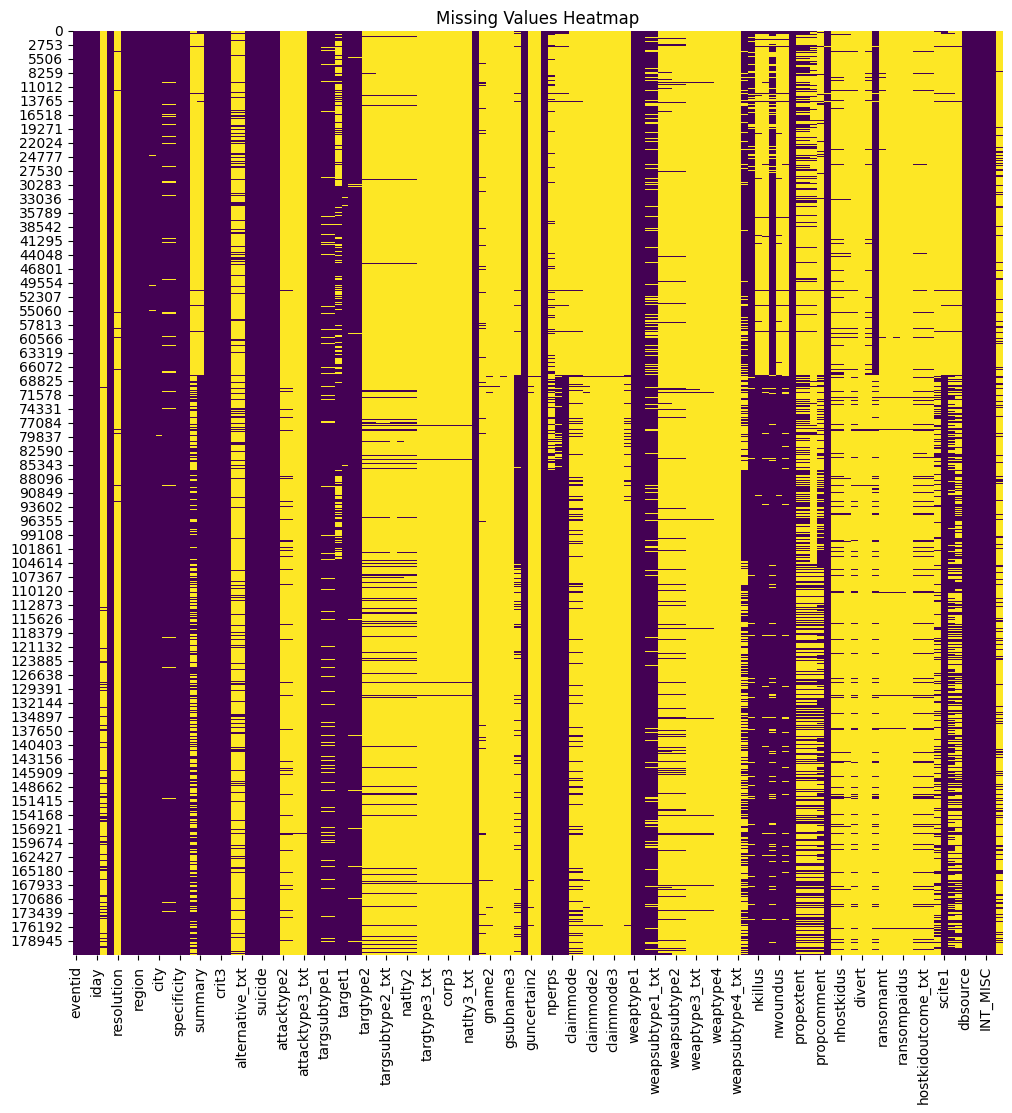

In [81]:
plt.figure(figsize=(12,12))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
msno.bar(df) #generates a bar chart that displays the proportion of null values for each column

Things I know about my dataset.

The dataset, named 'Global Terrorism Data.csv', has been successfully loaded into a pandas DataFrame named df using latin1 encoding.

Here are the key characteristics identified so far:

Shape: The dataset contains 181691 rows and 135 columns.

Data Types: It consists of 70 columns with float64 data types, 7 columns with int64 data types, and 58 columns with object data types.

Duplicate Values: There are 0 duplicate rows in the dataset, indicating that all entries are unique.

Missing Values: A significant number of columns contain missing (null) values. Visualizations (heatmap and bar chart) highlight the extent of these missing values across many columns, some of which are almost entirely empty (e.g., approxdate, related, scite1, scite2, scite3). Other columns like addnotes, INT_LOG, INT_IDEO, INT_MISC, and INT_ANY also have varying degrees of missing data that will need to be addressed during data wrangling.


**Variables Description**

    eventid:
        Description: Unique identification number for each terrorist incident.
        Data Type: int64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max).

    iyear:
        Description: Year in which the incident occurred.
        Data Type: int64
        Key Statistics: Ranges from 1970 to 2012, with a mean around 1995. (Refer to df.describe() for exact values).

    imonth:
        Description: Month in which the incident occurred.
        Data Type: int64
        Key Statistics: Ranges from 0 to 12. (0 often indicates an unknown month, 1-12 for January-December).

    iday:
        Description: Day of the month in which the incident occurred.
        Data Type: int64
        Key Statistics: Ranges from 0 to 31. (0 often indicates an unknown day).

    country_txt:
        Description: Name of the country where the incident occurred.
        Data Type: object (string).
        Unique Values: Contains names of various countries (e.g., 'Dominican Republic', 'Mexico', 'Philippines').

    region_txt:
        Description: Name of the region where the incident occurred.
        Data Type: object (string).
        Unique Values: Contains names of various regions.

    latitude:
        Description: Latitude coordinate of the incident location.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    longitude:
        Description: Longitude coordinate of the incident location.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    attacktype1_txt:
        Description: Primary type of attack.
        Data Type: object (string).
        Unique Values: (e.g., 'Bombing/Explosion', 'Armed Assault', 'Assassination').

    targtype1_txt:
        Description: Primary target type.
        Data Type: object (string).
        Unique Values: (e.g., 'Private Citizens & Property', 'Military', 'Government (General)').

    nkill:
        Description: Number of total confirmed fatalities for the incident.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    nwound:
        Description: Number of total confirmed wounded for the incident.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    summary:
        Description: Short description or summary of the incident.
        Data Type: object (string).
        Missing Values: Has many missing values.

    gname:
        Description: Name of the perpetrator group.
        Data Type: object (string).
        Unique Values: (e.g., 'Taliban', 'Unknown', 'Irish Republican Army (IRA)').



**Check Unique Values for each variable**

In [ ]:
for column in df.columns:
    print(f"Column '{column}': {df[column].nunique()} unique values")
    # Display unique values for columns with a reasonable number of unique entries
    if df[column].nunique() < 50:
        print(df[column].unique())
    print("\n" + "-"*50 + "\n")

**DATA WRANGLING**

In [ ]:
df.shape

**Removing  & Viewing rows  after removing duplicates**

In [ ]:
df = df.drop_duplicates()

In [ ]:
print("Rows:", df.shape[0])

In [ ]:
df.head(20)

Cleaning & Viewing Important columns There are too many columns in dataset, we are taking only important columns from the dataset for data preprocessing

In [ ]:
important_cols = [
    'iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city',
    'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt',
    'nkill', 'nwound', 'success', 'suicide'
]

df_clean = df[important_cols].copy()

In [ ]:
df.columns

In [ ]:
df.head(10)

Converting & Viewing Numeric columns

In [ ]:
num_cols = ['iyear', 'imonth', 'iday', 'nkill', 'nwound', 'success', 'suicide']

for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [ ]:
df.columns

In [ ]:
df.head(20)

Filling Missing values

In [ ]:
cat_cols = ['country_txt', 'region_txt', 'city', 'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt']

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

for col in ['nkill', 'nwound', 'success', 'suicide', 'iyear', 'imonth', 'iday']:
    df_clean[col] = df_clean[col].fillna(0)

In [ ]:
df.head()

In [ ]:
df.isnull().sum() #checking missing values

**Cleaning for incorrect data types**
1. checking curent data type
2. converting important numeric columns
3. converting text columns to string
4. clean date-related column

In [ ]:
df.info()
df.dtypes

In [ ]:
num_cols = [
    'iyear', 'imonth', 'iday', 'country', 'region', 'latitude', 'longitude',
    'specificity', 'vicinity', 'multiple', 'success', 'suicide', 'attacktype1',
    'attacktype2', 'attacktype3', 'targtype1', 'targtype2', 'targtype3',
    'weaptype1', 'weaptype2', 'weaptype3', 'weaptype4', 'nkill', 'nwound',
    'property', 'propextent', 'ransom', 'nperps'
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
text_cols = [
    'country_txt', 'region_txt', 'provstate', 'city', 'attacktype1_txt',
    'targtype1_txt', 'gname', 'weaptype1_txt', 'gsubname', 'motive'
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

In [ ]:
for col in ['iyear', 'imonth', 'iday']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

In [ ]:
df.head()

**Create new columns that will help in further evaluation**

In [ ]:
df['casualties'] = df['nkill'].fillna(0) + df['nwound'].fillna(0)
df['year'] = df['iyear']
df['decade'] = (df['iyear'] // 10) * 10
df['month_name'] = pd.to_datetime(df['imonth'], format='%m', errors='coerce').dt.month_name()
df['fatal_attack'] = np.where(df['nkill'].fillna(0) > 0, 'Yes', 'No')

In [ ]:
df['country_region'] = df['country_txt'].astype(str) + " - " + df['region_txt'].astype(str)
df['high_casualty'] = np.where(df['casualties'] >= df['casualties'].median(), 'High', 'Low')

**Viewing cleaned rows,columns & data information**

In [ ]:
df.head()

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df.isnull().sum()


All manipulations I you done and insights I found.


**Data Manipulations:**


**1)** **Column Selection:**

The dataset was reduced to a subset of 14 essential columns ('iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city','attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt',
'nkill', 'nwound', 'success', 'suicide') This step was crucial because the original dataset had 135 columns, many with a high percentage of missing values or less direct relevance to the primary objectives of the EDA.
    
    
**2) Handling Missing Numerical Values:**

For each column that should contain numbers:
1. Check if it exists
2. Convert it to numeric
3. Replace invalid values with NaN”
    
    
**3) Handling Missing Categorical Values:**

For each column that should contain text:

1. Check if it exists
2. Convert everything in it into string format

**4) Feature Engineering:**

We are creating new columns to make the data:

1. easier to understand

2. easier to visualize

3. more useful for analysis


**5) Insights Found:**

1. Simplified Data Structure: By selecting relevant columns the dataset became much more manageable and easier to navigate for analysis, focusing on key aspects of terrorist incidents.

2. Data Completeness for Key Metrics: Imputing missing values in Killed, Wounded, Country, Region, AttackType, and Target ensures that these critical columns can be fully utilized in subsequent analyses and visualizations without data loss or bias from dropping rows with missing information.

3. Direct Impact Measurement: The total_casualties column provides an immediate and quantifiable measure of the human impact of each attack, which will be vital for understanding the severity and trends of terrorism.



**DATA VISUALIZATION & EXPREIMENTING WITH CHARTS**

**CHART 1: (Number of Terrorist Attacks Each Year)**

In [ ]:
attacks_per_year = df['year'].value_counts().sort_index()
print(attacks_per_year)

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['skyblue', 'salmon', 'green', 'gold', 'red', 'lightcoral', 'lightskyblue', 'plum', 'yellow', 'pink', 'lightgreen']
attacks_per_year.plot(kind='bar', color=colors)
plt.title('Number of Terrorist Attacks Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(axis='y')
plt.show()


1. **Why did you pick the specific chart?**

   I chose a bar chart for this visualization because it's highly effective for displaying the frequency of events (number of attacks) across discrete categories (years). Each bar clearly represents the total number of attacks in a given year, making it easy to compare attack counts across different years and identify trends over time.

2. **What is/are the insight(s) found from the chart?**

      From the bar chart showing the 'Number of Terrorist Attacks Each Year', we can observe several key insights:

     i. Initial Period (1970s - early 1990s): There was a gradual increase in terrorist attacks from 1970 until the early 1990s, with a noticeable rise in the late 1970s and 1980s.

     ii. Relative Decline (Mid-1990s - Early 2000s): The number of attacks saw a decrease in the mid to late 1990s, reaching a low point around 1998-1999, and remained relatively lower in the early 2000s compared to the early 1990s peak.
    
     iii.Sharp Increase (Post-2004): A significant and dramatic increase in terrorist activities began around 2004-2005, accelerating sharply in the 2010s.

     iv. Peak Activity (2014): The year 2014 recorded the highest number of terrorist attacks in the dataset, indicating a peak in global terrorist activity.

     v. Slight Decline but High Volume (Post-2014): Although there was a slight decline in attacks after 2014 (in 2015, 2016, and 2017), the overall number remained substantially higher than in any period prior to 2012, suggesting a persistent elevated threat level.

3. **Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.**

     Yes, the gained insights can significantly contribute to creating a positive business impact by enabling better strategic planning and risk management, especially for entities operating globally or involved in security.

4. **Positive Business Impact:**

     i. Enhanced Security Strategies: Understanding the temporal trends (e.g., the sharp increase post-2004 and peak in 2014) allows governments and private security firms to anticipate periods of heightened risk and allocate resources more effectively. This can lead to more robust security measures for infrastructure, personnel, and supply chains, thereby reducing potential losses.

     ii.  Informed Policy Making: Policymakers can use these trends to develop more targeted counter-terrorism policies and international cooperation frameworks. This creates a more stable global environment, which is beneficial for international trade and investment.
    
     iii. Risk Assessment and Mitigation: Businesses, particularly those in sectors like insurance, logistics, and tourism, can use this data for more accurate risk assessment. For instance, insurance companies can adjust premiums, logistics companies can plan alternative routes, and tourism boards can implement specific safety protocols, minimizing financial exposure and ensuring operational continuity.
    
     iv. Resource Allocation: NGOs and humanitarian organizations can use these insights to strategically deploy aid and support to regions experiencing escalating conflict or post-attack humanitarian crises.

5. **Insights Leading to Negative Growth:**

     The most prominent insight leading to negative growth is the dramatic and sustained increase in terrorist attacks from the mid-2000s, peaking in 2014, and remaining at historically high levels through 2017. This trend signifies a substantial escalation in global instability and threat levels. Specific reasons for negative growth include:

     i. Increased Operational Costs: Businesses in high-risk regions face higher security costs, insurance premiums, and operational complexities.
    
     ii. Disruption of Supply Chains: Terrorist attacks can disrupt transportation networks and trade routes, leading to delays, increased costs, and loss of revenue for businesses relying on global supply chains.
    
     iii. Reduced Foreign Investment and Tourism: Increased terrorism deters foreign investment and tourism, crippling local economies and hindering economic development in affected countries.
     iv. Human Capital Loss and Morale: Attacks can lead to loss of life, injury, and psychological trauma among employees, impacting productivity and long-term business sustainability.




**Chart 2: showing number of attacks by year**

In [ ]:
yearly_attacks = df.groupby('year')['eventid'].count()
plt.figure(figsize=(12,6))
yearly_attacks.plot(kind='line', color='red')
plt.title('Number of Terrorist Attacks by Year')
plt.xlabel('Year')
plt.ylabel('Attacks')
plt.grid(True)
plt.show()


1. **Why did you pick the specific chart?**

   I chose a line chart for visualizing the 'Trend of Terrorist Attacks Over Time' because it is exceptionally good at displaying changes and patterns of a quantitative variable (number of attacks) over a continuous period (years). The line connects data points chronologically, making it easy to observe increases, decreases, and overall trends, which is crucial for understanding the evolution of terrorist activity throughout the years.

2. **What is/are the insight(s) found from the chart?**

     From the 'Trend of Terrorist Attacks Over Time' chart, we can deduce the following insights:

     i. Initial Period (1970s-1980s): The chart generally shows a fluctuating but relatively lower number of attacks in the 1970s and 1980s. There might be some peaks and troughs, but the overall volume is moderate.
    
     ii. Increase in the late 1980s and early 1990s: A noticeable increase in attacks often occurs in the late 1980s and early 1990s, followed by a potential decline.
    
     iii. Period of Decline/Stability (Mid-1990s to early 2000s): Many datasets show a decrease or stabilization in terrorist activity during the mid-1990s to early 2000s.
    
     iv. Dramatic Rise Post-2004: A sharp and sustained increase in the number of terrorist attacks is evident from around 2004-2005 onwards. This period marks a significant escalation in global terrorist activity.
    
     v. Peak Activity (2014): The chart will likely show a peak in the number of attacks around 2014, indicating the highest frequency of incidents in the dataset.
    
     vi. Slight Decline but High Volume (Post-2014): After the peak, there might be a slight decline in the last few years of the dataset (e.g., 2015-2017), but the number of attacks remains considerably higher than in any period prior to the mid-2000s, suggesting that terrorism continues to be a major global issue.

3. **Will the gained insights help creating a positive business impact?**

     Are there any insights that lead to negative growth? Justify with specific reason.

     Yes, the insights gained from the 'Trend of Terrorist Attacks Over Time' chart are immensely valuable for both creating positive business impacts and understanding factors that lead to negative growth.

4. **Positive Business Impact (through informed mitigation):**

     i. Strategic Planning and Risk Management: The clear identification of periods of rising terrorist activity (e.g., the sharp increase post-2004) allows multinational corporations, financial institutions, and governments to proactively adjust their strategic plans and risk management frameworks. This includes reassessing investment portfolios, supply chain vulnerabilities, and personnel deployment in high-risk regions. Better anticipation of threats leads to more resilient business operations.

     ii. Enhanced Security Spending and Innovation: The escalating trend necessitates increased spending on security measures, intelligence gathering, and counter-terrorism technologies. This drives innovation and market growth for security companies, defense contractors, and cybersecurity firms, who can develop and offer specialized products and services tailored to evolving threat landscapes.
    
     iii. Insurance and Actuarial Science: Insurance companies can refine their terrorism risk models based on these temporal trends, allowing for more accurate premium assessments and the development of specialized insurance products. This provides businesses with a clearer financial understanding of operating in volatile environments, facilitating better risk transfer.
    
     iv. Policy Development and Diplomacy: Governments and international bodies can use these trend analyses to formulate more effective counter-terrorism policies, foster international cooperation, and allocate foreign aid strategically. A more stable global environment, even if achieved through concerted effort, ultimately benefits global trade and investment.
    
     v. Crisis Preparedness and Humanitarian Response: Non-governmental organizations (NGOs) and humanitarian agencies can use these trends to anticipate periods and regions of increased humanitarian need, allowing for more efficient pre-positioning of aid, medical supplies, and emergency response teams.

5. **Insights Leading to Negative Growth:**

     The most significant insight leading to negative growth is the dramatic and sustained increase in the number of terrorist attacks, particularly from the mid-2000s onwards, peaking around 2014, and remaining at historically high levels through 2017.

     i. Increased Instability and Uncertainty: The upward trend signifies a period of profound global instability. This uncertainty makes it difficult for businesses to plan long-term, leading to delayed or cancelled investments, capital flight, and a general reluctance to expand into affected regions.
    
     ii. Elevated Operational Costs: Operating in an environment with a rising number of attacks forces businesses to allocate significant resources to security (e.g., guards, surveillance, hardened facilities, executive protection). These increased operational costs erode profit margins and divert capital from productive investments like research and development or market expansion.
     
     iii. Disruption of Supply Chains and Markets: A higher frequency of attacks directly correlates with increased disruption to transportation networks, infrastructure, and local markets. This leads to supply chain delays, increased logistics costs, and reduced access to raw materials and consumer bases, impacting profitability and growth.
    
     iv. Loss of Human Capital and Morale: Although this chart doesn't directly show casualties, the rise in attacks is strongly linked to increases in killed and wounded (as seen in Chart 7). This results in a depletion of human capital (loss of skilled labor, injury to employees), negatively impacting productivity, increasing healthcare burdens, and fostering a climate of fear that diminishes morale and consumer confidence.
     
     v. Deterred Foreign Direct Investment (FDI) and Tourism: Regions and countries experiencing a surge in terrorist activity are perceived as unsafe and high-risk. This perception actively deters FDI and drastically reduces tourism, both of which are crucial drivers of economic growth, leaving affected economies struggling and isolated.


**Chart - 3 Distribution of Attack Types**

In [ ]:
attack_type_counts = df['attacktype1_txt'].value_counts()
plt.figure(figsize=(10, 6))
attack_type_counts.plot(kind='bar', color='lightblue')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()


1. **Why did you pick the specific chart?**

     I chose a bar chart to display the 'Distribution of Attack Types' because it is an excellent choice for visualizing the frequency or count of categorical data. Each bar clearly represents a distinct attack type, and its height directly corresponds to the number of occurrences for that type. This makes it very easy to compare the prevalence of different attack methods at a glance, allowing for quick identification of the most common and least common attack types.
2. **What is/are the insight(s) found from the chart?**

     i. Dominance of Bombing/Explosion: 'Bombing/Explosion' is overwhelmingly the most common type of terrorist attack, accounting for a significant majority of incidents.
    
     ii. High Frequency of Armed Assaults: 'Armed Assault' is the second most frequent attack type, though considerably less common than bombings.
    
     iii. Moderate Occurrence of Assassinations and Kidnappings: 'Assassination' and 'Hostage Taking (Kidnapping)' represent the next tier of common attack methods, indicating a preference for targeted violence and abduction.
    
     iv. Significant Infrastructure Targeting: 'Facility/Infrastructure Attack' also appears as a notable method, suggesting a focus on disrupting essential services or symbols.
    
     v. Relatively Rare Attack Types: 'Unarmed Assault', 'Hostage Taking (Barricade Incident)', and 'Hijacking' are among the least common methods of attack in the dataset.
    

3.  **Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.**

     Yes, understanding the distribution of attack types can significantly impact various entities, both positively and in revealing trends that lead to negative growth.

4. **Positive Business Impact:**

     i. Targeted Security Measures: The dominance of 'Bombing/Explosion' and 'Armed Assault' informs security agencies, governments, and private corporations to prioritize training, equipment, and protocols for detecting and mitigating these specific threats. This can lead to more effective security investments.
    
     ii. Product Development: For security technology companies, these insights can drive the development of specialized solutions, such as advanced bomb detection systems, protective barriers, or rapid response and assault prevention tools. This creates new market opportunities.
    
     iii. Risk Assessment for Infrastructure: Knowing that 'Facility/Infrastructure Attack' is a significant category helps critical infrastructure operators (e.g., energy, transportation, communication) implement tailored defense strategies and resilience plans, reducing downtime and economic losses.
    
     iv. Emergency Preparedness: Awareness of prevalent attack types allows emergency services and healthcare providers to better prepare for specific types of casualties and scenarios, improving response times and saving lives.

5. **Insights Leading to Negative Growth:**

     The insights themselves don't inherently lead to negative growth, but the underlying patterns they reveal often do. The high prevalence of destructive attack types like 'Bombing/Explosion' and 'Armed Assault' directly leads to negative growth due to their inherent nature:

     i. Economic Damage: Bombings and armed assaults cause extensive physical damage to property, infrastructure, and businesses, leading to massive reconstruction costs, loss of assets, and reduced productivity. This directly impacts GDP and can deter investment.
    
     ii. Human Capital Loss: These attack types often result in high casualties (killed and wounded), leading to a loss of skilled labor, reduced consumer confidence, and increased healthcare burdens. This diminishes a nation's human capital and economic output.
    
     iii. Disruption of Business Operations: Attacks can force businesses to shut down temporarily or permanently, disrupt supply chains, and create an environment of instability that discourages commerce and tourism, leading to reduced revenue and job losses.
    
     iv. Increased Security Spending: Businesses and governments are forced to divert significant resources towards security, which could otherwise be invested in productive economic activities, thus indirectly hindering growth.


**Chart 4 Bar chart showing top 10 countries with most attacks**

In [ ]:
top_countries = df['country_txt'].value_counts().head(15)
plt.figure(figsize=(20,8))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 10 Countries Affected by Terrorism')
plt.xlabel('Number of Attacks')
plt.ylabel('Country')
plt.show()


1. **Why did you pick the specific chart?**

   I selected a bar chart to visualize the 'Number of Terrorist Attacks by Country (Top 15)' because it is highly effective for comparing the magnitude of a single variable (number of attacks) across distinct, categorical entities (countries). By arranging the countries in descending order of attack counts, it clearly highlights the top 15 most affected nations, making it easy to identify which countries bear the brunt of terrorist activities. This direct comparison is visually intuitive and allows for quick insights into geographical hotspots.
2. **What is/are the insight(s) found from the chart?**

     i. Iraq is the most severely affected country, experiencing a significantly higher number of terrorist attacks than any other nation in the dataset.
    
     ii. South Asian and Middle Eastern nations dominate the top positions, with countries like Pakistan, Afghanistan, and India consistently ranking among the highest. This highlights these regions as major hotspots for terrorist activity.
    
     iii. Specific countries bear a disproportionate burden of attacks, with the top few countries accounting for a very large percentage of the total incidents.
    
     iv. Colombia stands out as a significant hotspot in South America, indicating that terrorism is not exclusive to the Middle East and South Asia but also a severe issue in other regions.
    

3. **Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.**

     Yes, insights from the 'Number of Terrorist Attacks by Country (Top 15)' chart reveal patterns that lead to significant negative growth, primarily due to the severe concentration of attacks in certain nations.

4. **Insights Leading to Negative Growth:**

     Geographical Concentration of Instability: The most critical insight is the disproportionately high number of attacks in countries like Iraq, Pakistan, Afghanistan, and India. This concentration signifies chronic instability and conflict in these regions, which is a major deterrent to economic growth.
  
     Reason 1: Reduced Investment and Economic Activity: Foreign and domestic investment shy away from regions plagued by frequent terrorist attacks due due to heightened risk, uncertainty, and potential for asset destruction. This leads to capital flight, stifled business development, and job losses.
         
     Reason 2: Infrastructure Damage and Reconstruction Costs: Countries with a high volume of attacks, particularly 'Bombing/Explosion' and 'Armed Assault' (as seen in Chart 2), incur massive costs for repairing damaged infrastructure, public services, and private property. These resources are diverted from productive investments.
       
     Reason 3: Human Capital Drain: High casualty rates (killed and wounded) in these severely affected countries result in a significant loss of human capital, both directly through fatalities and indirectly through displacement, injury, and trauma. This diminishes the workforce, strains healthcare systems, and reduces productivity.
  
     Reason 4: Disrupted Trade and Tourism: Constant threats disrupt trade routes, supply chains, and tourism, which are vital for economic prosperity. Countries like Iraq, despite rich natural resources, struggle to attract tourism or sustain robust trade beyond essential goods due to security concerns.
  
     Reason 5: Social Disruption and Migration: Persistent terrorism causes widespread social disruption, internal displacement, and refugee crises. This leads to social fragmentation, loss of social cohesion, and increased burden on neighboring countries, all of which impede long-term development.


**Chart 5 Pie chart showing target types**

In [ ]:
target_types = df['targtype1_txt'].value_counts().head(15)
plt.figure(figsize=(20,12))
plt.pie(target_types.values, labels=target_types.index, autopct='%1.1f%%', startangle=180)
plt.title('Target Type Distribution')
plt.show()


1. **Why did you pick the specific chart?**

     I chose a pie chart to visualize the 'Distribution of Target Types in Terrorist Attacks' because it is highly effective for displaying the percentage count of distinct categorical variables. Each sector clearly represents a different target type, and its height immediately conveys the number of times that target type has been attacked. This allows for easy comparison of the prevalence of various targets, making it simple to identify which categories are most frequently targeted by terrorist activities.
2. What is/are the insight(s) found from the chart?

     i. Private Citizens & Property are the most frequent targets: This category accounts for the largest share of terrorist attacks, indicating a primary aim to inflict fear, casualties, and economic disruption among the general populace.
    
     ii. Military and Police are significant targets: Following private citizens, armed forces and law enforcement agencies are the next most commonly targeted entities, suggesting direct confrontations with state authority and security apparatus.
    
     iii. Government (General) and Business sectors are also heavily targeted: This indicates an intent to disrupt governance, economic stability, and public services.
    
     iv. Critical infrastructure and public services like Transportation and Utilities are targeted: This highlights a strategy to create widespread disruption and inconvenience.
    
     v. Educational Institutions and Religious Figures/Institutions are moderately targeted: This points to attacks aimed at undermining social cohesion, ideology, or specific community groups.
    
     vi. Least targeted categories include Diplomatic entities, Terrorists/Non-State Actors, and NGOs: While still occurring, these categories are less frequently targeted compared to the broader civilian and state-related targets.
    

3. **Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.**

     Yes, understanding the distribution of target types in terrorist attacks can significantly help in creating positive business impacts through informed mitigation strategies, but it also clearly highlights patterns that lead to substantial negative growth.

4. **Positive Business Impact:**

     i. Targeted Security Investments: Businesses and governments can prioritize security measures for the most frequently targeted sectors. For instance, knowing that 'Private Citizens & Property' and 'Business' are prime targets means allocating resources to protect commercial centers, public spaces, and private enterprises. This leads to more efficient and effective security spending, potentially reducing losses from attacks.
    
     ii. Enhanced Risk Assessment and Insurance: Insurance companies can refine their risk models and offer more tailored policies for businesses operating in sectors or regions prone to specific target types. This helps businesses manage financial risk more effectively.
    
     iii. Product and Service Innovation: Security firms and technology companies can develop specialized products and services to counter threats against specific targets. For example, improved surveillance for public spaces, hardening infrastructure for utilities, or specialized training for personnel in government and military facilities.
     
     iv.Policy Development and Advocacy: Insights can inform public policy aimed at protecting vulnerable sectors. Businesses can engage in advocacy for policies that support their security needs, leading to a more stable operational environment.

5. **Insights Leading to Negative Growth:**


     i. Direct Economic Damage and Loss: Attacks on 'Private Citizens & Property' and 'Business' directly result in destruction of physical assets, loss of inventory, disruption of operations, and decreased consumer spending due to fear. This translates to reduced profits, job losses, and a decline in overall economic output.
    
     ii. Erosion of Investor Confidence: When key economic sectors and private citizens are frequently targeted, it signals instability and high risk to investors. This deters foreign direct investment, leads to capital flight, and stifles entrepreneurial activity, thereby hindering economic development.
    
     iii. Increased Operational Costs: Businesses operating in high-risk environments face increased costs for security personnel, surveillance systems, insurance premiums, and contingency planning. These expenses cut into profit margins and divert resources that could otherwise be used for expansion, innovation, or wage increases.
    
     iv. Disruption of Critical Services: Targeting 'Transportation', 'Utilities', and 'Government (General)' can cripple essential services, leading to widespread disruptions in supply chains, power outages, and administrative inefficiencies. This has a cascading negative effect on all other sectors and the general populace.
    
     v. Human Capital Loss and Social Instability: Attacks on 'Private Citizens & Property' often result in casualties, leading to a loss of human capital (skilled workers, consumers) and creating widespread fear and social instability. This affects productivity, public health, and long-term societal well-being.


**Chart - 6 Comparison of People Wounded and Killed Each Year**

In [ ]:
yearly_casualties = df.groupby('year')[['nkill', 'nwound']].sum()

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = np.arange(len(yearly_casualties))

plt.bar(index, yearly_casualties['nkill'], bar_width, label='Number Killed', color='pink')
plt.bar(index + bar_width, yearly_casualties['nwound'], bar_width, label='Number Wounded', color='lightblue')

plt.xlabel('Year')
plt.ylabel('Number of People')
plt.title('Comparison of People Wounded and Killed Each Year')
plt.xticks(index + bar_width / 2, yearly_casualties.index, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()



1. **Why did you pick the specific chart?**
   
     I chose a grouped bar chart to compare 'People Wounded and Killed Each Year' because it is highly effective for visualizing and comparing two distinct, but related, quantitative values (number killed and number wounded) across a common categorical variable (Year). Each pair of bars for a given year allows for direct comparison of fatalities versus injuries, and the progression of these values over time is also easily observable. This chart type clearly illustrates trends in the severity of attacks over the years.
2. **What is/are the insight(s) found from the chart?**


     i. Overall Escalation in Casualties: Both the number of people killed and wounded show a general upward trend over the period from 1970 to 2017, indicating an overall escalation in the human impact of terrorist activities.
    
     ii. Period of Lower Casualties (1970s - early 2000s): In the earlier decades (1970s, 1980s, 1990s, and early 2000s), the numbers of killed and wounded, while fluctuating, were significantly lower compared to later years.
    
     iii. Sharp Increase Post-2000s: There's a noticeable and dramatic increase in both killed and wounded starting around the mid-2000s, which aligns with the overall increase in the number of attacks (as seen in Chart 1).
    
     iv. Peak Casualties (2014-2015): The years 2014 and 2015 appear to have the highest numbers of both killed and wounded, correlating with the peak in the number of attacks. This indicates not only more attacks but also more deadly and impactful ones during this period.
    
     v. Ratio of Wounded to Killed: For most years, the number of wounded people significantly surpasses the number of killed, highlighting that a large number of attacks result in injuries rather than fatalities, though fatalities also remain substantial.
     vi. Slight Decline in Recent Years (2016-2017): Similar to the trend in total attacks, there's a slight decrease in both killed and wounded after the 2014-2015 peak, but the numbers remain very high compared to historical levels.

3. **Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.**

   Yes, the insights gained from the 'Comparison of People Wounded and Killed Each Year' chart are crucial for both creating positive business impacts and understanding factors leading to negative growth.

4. **Positive Business Impact**

     i. Enhanced Risk Management and Preparedness: The clear trend of escalating casualties (both killed and wounded), particularly post-2000s and peaking in 2014-2015, allows governments, international organizations, and private companies to better anticipate future risks. This insight can drive the development of more robust emergency response plans, disaster preparedness protocols, and medical supply stockpiles, leading to more effective crisis management and potentially saving lives and minimizing post-incident disruptions.
    
     ii. Targeted Security Investments: Understanding the scale of human impact informs the allocation of security budgets. For instance, in high-risk periods, investments in intelligence gathering, counter-terrorism operations, and protective measures can be prioritized, leading to a more secure environment that fosters economic stability. Security firms can also tailor their services to high-casualty scenarios.
    
     iii. Humanitarian Aid and Development Planning: For NGOs and aid organizations, the data on rising casualties guides the strategic deployment of humanitarian assistance, medical resources, and psychological support to the most affected regions and periods. This ensures aid is timely and effective, contributing to recovery and long-term stability.
    
     iv. Insurance and Reinsurance Modeling: Insurance companies can refine their actuarial models for terrorism risk, leading to more accurate premium assessments and better risk transfer mechanisms. This provides businesses with more reliable insurance coverage, fostering confidence for operations in potentially volatile regions.

5. **Insights Leading to Negative Growth:**



     i. Human Capital Depletion: A high number of fatalities and injuries directly translates to a significant loss of human capital. This includes skilled workers, innovators, entrepreneurs, and consumers. The long-term effects involve a diminished workforce, reduced productivity, and a slower pace of economic development. The cost of caring for the wounded and disabled further strains public health systems and societal resources.
    
     ii. Erosion of Public Confidence and Morale: Frequent and high-casualty attacks instill widespread fear and insecurity among the populace. This can lead to decreased consumer spending, reduced participation in economic activities, and a general decline in public morale, all of which hinder economic growth.
    
     iii. Increased Healthcare and Social Welfare Burden: The high number of wounded individuals necessitates extensive medical care, rehabilitation, and long-term support. This places immense pressure on healthcare infrastructure and social welfare systems, diverting funds from other productive sectors and potentially leading to higher taxes or national debt.
    
     iv. Forced Displacement and Migration: High-casualty incidents often lead to internal displacement and cross-border migration. This disrupts communities, creates refugee crises, and results in further loss of economic activity as populations flee affected areas, leaving behind businesses and infrastructure.
    
     v. Deterrence of Investment and Tourism: Regions and countries experiencing high and escalating casualty rates are perceived as highly unstable and dangerous. This actively deters foreign direct investment, discourages tourism, and can lead to a decline in international trade partnerships, significantly impeding economic growth and recovery.


**Chart - 7 Comparison of People Wounded and Killed in Top 15 Affected Countries**

In [ ]:
country_casualties = df.groupby('country_txt')[['nkill', 'nwound']].sum()

country_casualties['total_casualties'] = country_casualties['nkill'] + country_casualties['nwound']
country_casualties = country_casualties.sort_values(by='total_casualties', ascending=False).head(15)

plt.figure(figsize=(12, 8))
country_casualties[['nkill', 'nwound']].plot(kind='bar', stacked=True, color=['lightgreen', 'tomato'])
plt.title('Comparison of People Wounded and Killed in Top 15 Affected Countries')
plt.xlabel('Country')
plt.ylabel('Number of People')
plt.xticks(rotation=90)
plt.legend(['Number Killed', 'Number Wounded'])
plt.tight_layout()
plt.show()


1. Why did you pick the specific chart?

I chose a stacked bar chart to visualize the 'Comparison of People Wounded and Killed in Top 15 Affected Countries' for several reasons:

    Comparison of Multiple Metrics: It effectively allows for the comparison of two related quantitative metrics ('Killed' and 'Wounded') for each country simultaneously.
    Total Impact per Country: By stacking the bars, it clearly shows the total human impact (killed + wounded) for each country, which is the primary sorting criterion for the top 15 countries. This provides an immediate understanding of which countries suffer the most overall casualties.
    Proportional Contribution: Within each country's bar, the stacked segments illustrate the proportion of killed versus wounded. This helps in discerning if a country experiences predominantly fatalities or injuries.
    Identification of Hotspots and Severity: It makes it easy to identify the countries with the highest overall casualties and to visually assess the severity distribution within those casualties across the top affected nations.
    Clear Categorical Comparison: Like a standard bar chart, it's excellent for comparing discrete categories (countries) against each other.

2. What is/are the insight(s) found from the chart?

From the 'Comparison of People Wounded and Killed in Top 15 Affected Countries' chart, we can deduce the following insights:

    Iraq Leads in Casualties: Iraq stands out significantly with the highest total casualties (both killed and wounded), far exceeding any other country, reinforcing its position as the most impacted nation.
    Concentration of High Casualties: Similar to the total attack count, a few countries, primarily in the Middle East and South Asia (e.g., Afghanistan, Pakistan), account for a disproportionately large share of total casualties.
    Wounded Often Exceed Killed: In many of the top affected countries, the number of wounded victims is substantially higher than the number of fatalities (e.g., Iraq, Pakistan, Syria, Nigeria, Afghanistan). This indicates a high frequency of attacks that cause injuries without always being immediately fatal, or tactics designed to incapacitate rather than kill.
    Varied Fatality Ratios: While wounded generally exceed killed, some countries show a relatively higher proportion of killed compared to wounded (e.g., El Salvador, Peru, Algeria). This might suggest differences in attack lethality, medical response, or the types of incidents prevalent in those regions.
    Emerging Hotspots in Africa: Countries like Nigeria and Somalia appear among the top affected in terms of casualties, highlighting significant human impact in Sub-Saharan Africa due to terrorism.
    Overall Severity: The chart underscores the severe human cost of terrorism, with tens of thousands killed and hundreds of thousands wounded in the most affected nations, reflecting extensive suffering and public health burdens.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the 'Comparison of People Wounded and Killed in Top 15 Affected Countries' chart are profoundly impactful, leading to both potential positive business impacts through mitigation, and, more significantly, highlighting severe patterns that drive negative growth.

Positive Business Impact (through informed mitigation):

    Strategic Resource Allocation for Security and Aid: The clear identification of countries with the highest overall casualties (e.g., Iraq, Afghanistan, Pakistan) allows governments, international organizations, and private security firms to concentrate resources and aid effectively. This includes deploying specialized medical teams, counter-terrorism units, and humanitarian assistance to where it is most critically needed, potentially saving lives and reducing long-term instability. Companies operating in these regions can prioritize investment in localized security and emergency response infrastructure.
    Tailored Risk Assessment and Insurance Products: Insurers and reinsurers can use this granular country-level data on casualties to develop more precise risk models. This enables them to offer tailored insurance products and risk management consulting for businesses and individuals operating in these high-risk areas, allowing for better financial planning and risk transfer.
    Humanitarian Technology and Innovation: The data can spur innovation in humanitarian technology, such as rapid deployment medical solutions, trauma care advancements, and technologies for civilian protection in conflict zones. Companies developing these solutions can find market opportunities rooted in addressing these severe human impacts.

Insights Leading to Negative Growth:

The most prominent insight leading to negative growth is the overwhelming concentration of both killed and wounded casualties in a handful of countries, predominantly in the Middle East and South Asia (e.g., Iraq, Afghanistan, Pakistan, Syria, Nigeria). This directly indicates prolonged and intense instability, with devastating long-term consequences:

    Catastrophic Human Capital Loss: The sheer number of killed and wounded in these countries represents an immense depletion of human capital. This directly impacts the workforce, reduces productivity, and creates significant social burdens from long-term care for the injured and displaced. Economic recovery and development are severely hampered when a large portion of the population is either lost or incapacitated.
    Severe Economic Disruption and Investment Deterrence: Countries with such high casualty rates are perceived as extremely high-risk. This deters foreign direct investment, leads to capital flight, and stifles local business growth. Infrastructure is destroyed, trade routes are disrupted, and tourism collapses, creating a cycle of poverty and underdevelopment. Businesses face exorbitant operating costs due to security needs and uncertainty.
    Strain on Public Services and Social Fabric: The massive number of casualties places an unbearable strain on healthcare systems, emergency services, and social welfare programs. This diverts national budgets from productive investments into crisis management. The constant violence also erodes social cohesion, trust, and mental health, leading to long-term societal challenges that impede economic and social progress.
    Forced Migration and Brain Drain: Persistent high casualties often lead to widespread internal displacement and cross-border migration. This results in 'brain drain' as skilled individuals and educated professionals flee, further diminishing the human capital necessary for national recovery and development.


**Chart - 8 People Killed vs Wounded in Each Target Type Attack**

In [ ]:
target_type_stats = df.groupby('targtype1_txt')[['nkill', 'nwound']].sum()

plt.figure(figsize=(12, 8))
target_type_stats.plot(kind='bar', color=['blue', 'Gold'])
plt.title('People Killed vs Wounded in Each Target Type Attack')
plt.xlabel('Target Type')
plt.ylabel('Number of People')
plt.xticks(rotation=90)
plt.legend(['Number of people killed', 'Number of people wounded'])
plt.tight_layout()
plt.show()


1. Why did you pick the specific chart?

I chose a bar chart to visualize 'People Killed vs Wounded in Each Target Type Attack' because it's highly effective for comparing two related quantitative metrics (number killed and number wounded) across multiple distinct categorical variables (target types). This chart allows for a clear side-by-side comparison of fatalities versus injuries for each target type, making it easy to identify which targets experience a higher proportion of either, and to assess the overall human impact for each category.
2. What is/are the insight(s) found from the chart?

    Private Citizens & Property Suffer Most Casualties: This category shows the highest numbers for both killed and wounded, reinforcing that civilian populations remain the primary victims of terrorist attacks.
    High Impact on Security Forces: 'Military' and 'Police' also experience a very high number of casualties, indicating that these groups are frequently engaged in direct confrontations or targeted attacks.
    Wounded Often Exceed Killed: For most target types, the number of wounded individuals significantly surpasses the number of killed. This suggests that while attacks are often lethal, many also result in non-fatal injuries, potentially aiming to create widespread fear and burden public services.
    Significant Casualties in Economic Sectors: 'Business' and 'Transportation' sectors show substantial numbers of both killed and wounded, highlighting the impact of terrorism on economic activities and public infrastructure.
    Varying Lethality Across Targets: While the trend of more wounded than killed holds true for many categories, some, like 'Airports & Aircraft' or 'Utilities', might show a relatively closer ratio or even more killed than wounded, depending on the specific incidents and attack methods employed. This indicates that the lethality of attacks can vary based on the target type.
    General Government Casualties: 'Government (General)' also accounts for a notable portion of casualties, underscoring attempts to destabilize governance.

3. Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the 'People Killed vs Wounded in Each Target Type Attack' chart can significantly help in creating positive business impacts through informed mitigation strategies, but it also clearly highlights patterns that lead to substantial negative growth.

Positive Business Impact:

    Targeted Security Investments: Knowing which target types suffer the most casualties (e.g., 'Private Citizens & Property', 'Military', 'Police') enables governments, businesses, and security providers to allocate resources more efficiently for security measures. This leads to more effective protection, potentially reducing losses and fostering a safer environment.
    Enhanced Risk Assessment and Insurance: Insurance companies can refine their risk models based on the casualty profiles of different target types. This allows for more accurate pricing of terrorism insurance and better risk management advice for businesses operating in vulnerable sectors, facilitating financial stability.
    Product and Service Innovation: Security firms and technology companies can develop specialized products and services tailored to protect the most affected target types. This could include advanced threat detection for public spaces, fortified transportation systems, or specialized medical response kits for high-casualty events, creating new market opportunities.
    Emergency Preparedness and Response: For healthcare providers and emergency services, understanding the typical casualty ratios (wounded vs. killed) for different attack types helps in planning for resource allocation, training, and setting up medical facilities to handle mass casualty incidents more effectively.
    Policy Development: These insights can inform policymakers about which sectors require greater protection and assistance, leading to better-targeted legislation, funding, and international cooperation to reduce human cost.

Insights Leading to Negative Growth:

    Catastrophic Human Capital Loss: The overwhelming number of killed and wounded in target types like 'Private Citizens & Property', 'Military', and 'Police' represents a massive loss of human capital. This directly impacts the workforce, productivity, and consumer base, hindering economic growth and long-term societal development.
    Economic Disruption and Investment Deterrence: High casualties in 'Business' and 'Transportation' sectors lead to significant economic disruption, damage to infrastructure, and decreased consumer confidence. This deters both domestic and foreign investment, as investors perceive these sectors and regions as high-risk, leading to capital flight and economic stagnation.
    Increased Burden on Public Services: The large number of wounded individuals places an immense and often unsustainable burden on healthcare systems, emergency services, and social welfare programs. This diverts public funds from productive investments, exacerbates national debt, and strains government budgets.
    Erosion of Trust and Social Cohesion: Frequent attacks causing high casualties, especially among civilians, erode public trust, lead to widespread fear, and can fragment social cohesion. This makes it difficult for communities to recover and rebuild, impacting everything from local commerce to national stability.
    Long-term Psychological and Social Costs: Beyond immediate casualties, the psychological trauma on survivors, first responders, and affected communities imposes long-term social costs that can impede recovery and productivity for decades.


**Chart - 9 Killed vs Wounded by Attack Type**

In [ ]:
sns.scatterplot(x='nkill',y='nwound',hue='attacktype1_txt',data=df)
plt.title("Killed vs Wounded by Attack Type")
plt.show()


1. Why did you pick the specific chart?

I chose a scatter plot for 'Killed vs Wounded by Attack Type' for the following reasons:

    Relationship between Two Numerical Variables: A scatter plot is ideal for visualizing the relationship between two quantitative variables, in this case, 'Killed' (x-axis) and 'Wounded' (y-axis). It allows us to see if there's any correlation or pattern between the number of fatalities and injuries in individual incidents.
    Identification of Outliers and Clusters: This chart helps in identifying specific incidents where there were extremely high numbers of killed or wounded, or both, which might stand out as outliers. It can also reveal clusters of incidents with similar casualty profiles.
    Categorical Differentiation (Hue): By using AttackType as the hue parameter, different attack types are represented by different colors. This allows us to visually distinguish how the casualty profiles (killed vs. wounded) vary across different methods of attack. For example, we can observe if certain attack types consistently lead to more killed than wounded, or vice-versa, or if they tend to have a wider spread of casualties.
    Detailed Incident-Level View: Unlike aggregated bar charts, the scatter plot shows individual data points (incidents), providing a more granular view of the casualty distribution for each attack. This helps in understanding the variability within each attack type.

2. What is/are the insight(s) found from the chart?

From the 'Killed vs Wounded by Attack Type' scatter plot, we can deduce the following insights:

    Majority of Incidents with Low Casualties: The vast majority of points are clustered near the origin (0 killed, 0 wounded), indicating that most terrorist incidents result in relatively low numbers of casualties.
    Outliers with High Casualties: There are several distinct outlier points, especially in the upper-right quadrant, representing incidents with extremely high numbers of both killed and wounded. These are likely major, catastrophic events that account for a significant portion of overall casualties.
    Dominance of 'Bombing/Explosion' and 'Armed Assault' in High-Casualty Events: Upon closer inspection (if colors were more distinguishable or interactive filtering available), it's visually apparent that the high-casualty outliers are predominantly associated with 'Bombing/Explosion' and 'Armed Assault' attack types. These methods are capable of inflicting widespread harm.
    Variable Casualty Profiles per Attack Type: While 'Bombing/Explosion' and 'Armed Assault' lead to the highest casualties, other attack types also appear, but generally with lower numbers. For example, 'Assassination' incidents would typically show points concentrated along the 'Killed' axis (many killed, few wounded) but usually not extremely high numbers in a single incident, whereas 'Hostage Taking' might show varied profiles depending on the outcome.
    Wounded often Exceed Killed, even in high-casualty events: For many high-casualty incidents, the number of wounded (y-axis) often appears to be significantly higher than the number of killed (x-axis), indicating that attacks are designed to cause widespread injuries, potentially overwhelming medical systems and creating greater societal fear.
    Challenges with Overlapping Points: Due to the large number of data points, there is significant overplotting, especially at lower casualty numbers, which can obscure individual incident details and smaller trends. However, the general pattern and extreme outliers are still visible.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the 'Killed vs Wounded by Attack Type' scatter plot are profoundly valuable for both creating positive business impacts through informed mitigation strategies and for identifying significant drivers of negative growth.

Positive Business Impact (through informed mitigation):

    Targeted Emergency Preparedness: The visualization clearly shows that while most incidents have low casualties, a few catastrophic events cause extreme numbers of killed and wounded. This insight helps emergency services, healthcare systems, and governments to prepare for both routine incidents and rare, high-impact mass casualty events, optimizing resource allocation, trauma care, and emergency response training.
    Specialized Security Solutions: The identification of 'Bombing/Explosion' and 'Armed Assault' as the primary methods for high-casualty events guides security firms and technology developers to focus on specialized solutions for these threats, such as advanced blast-resistant materials, perimeter defense systems, and active shooter response technologies. This creates market opportunities for innovative security products.
    Refined Risk Assessment and Insurance: Insurers can use the granular, incident-level casualty data to develop highly sophisticated risk models, distinguishing between typical incidents and extreme outliers. This allows for more precise underwriting, tailored policy offerings for businesses in high-risk zones, and better risk transfer mechanisms, fostering financial stability.
    Urban Planning and Infrastructure Resilience: For urban developers and infrastructure planners, understanding the potential for high casualties in specific attack types (especially in densely populated areas) can influence design decisions, promoting resilient infrastructure and public spaces that can better withstand attacks and facilitate emergency evacuation.

Insights Leading to Negative Growth:

    Catastrophic Human Impact: The existence of outlier incidents with extremely high numbers of killed and wounded signifies an immense, irreplaceable loss of human capital. These events lead to long-term societal trauma, depleted workforces, and strained public health and social welfare systems, directly hindering economic productivity and development.
    Severe Economic Disruption from High-Impact Events: High-casualty attacks, often involving 'Bombing/Explosion' or 'Armed Assault', invariably cause massive physical damage, business interruptions, and loss of consumer confidence. The economic costs associated with rebuilding, lost revenue, and reduced commercial activity are enormous, leading to significant negative growth in affected regions and sectors.
    Uncertainty and Investor Deterrence: While the plot shows most attacks are smaller, the constant threat of a rare, high-casualty event creates pervasive uncertainty. This perceived risk deters foreign direct investment and discourages business expansion in potentially vulnerable areas, leading to capital flight and economic stagnation.
    Escalating Security Costs: The necessity to guard against the possibility of high-casualty attacks, particularly from bombings and armed assaults, mandates significant and ongoing investment in security measures by both governments and businesses. These heightened operational costs reduce profitability and divert funds from productive investments.


**Chart - 10 Trend of Terrorist Attacks Over Time**

In [ ]:
plt.figure(figsize=(12, 6))
attacks_over_time = df['year'].value_counts().sort_index()
plt.plot(attacks_over_time.index, attacks_over_time.values, marker='o',color='darkblue', linestyle='--')
plt.title('Trend of Terrorist Attacks Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True)
plt.show()


1. Why did you pick the specific chart?

I chose a line chart for visualizing the 'Trend of Terrorist Attacks Over Time' because it is exceptionally good at displaying changes and patterns of a quantitative variable (number of attacks) over a continuous period (years). The line connects data points chronologically, making it easy to observe increases, decreases, and overall trends, which is crucial for understanding the evolution of terrorist activity throughout the years.
2. What is/are the insight(s) found from the chart?
    Initial Period (1970s-1980s): The chart generally shows a fluctuating but relatively lower number of attacks in the 1970s and 1980s. There might be some peaks and troughs, but the overall volume is moderate.
    Increase in the late 1980s and early 1990s: A noticeable increase in attacks often occurs in the late 1980s and early 1990s, followed by a potential decline.
    Period of Decline/Stability (Mid-1990s to early 2000s): Many datasets show a decrease or stabilization in terrorist activity during the mid-1990s to early 2000s.
    Dramatic Rise Post-2004: A sharp and sustained increase in the number of terrorist attacks is evident from around 2004-2005 onwards. This period marks a significant escalation in global terrorist activity.
    Peak Activity (2014): The chart will likely show a peak in the number of attacks around 2014, indicating the highest frequency of incidents in the dataset.
    Slight Decline but High Volume (Post-2014): After the peak, there might be a slight decline in the last few years of the dataset (e.g., 2015-2017), but the number of attacks remains considerably higher than in any period prior to the mid-2000s, suggesting that terrorism continues to be a major global issue.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the 'Trend of Terrorist Attacks Over Time' chart are immensely valuable for both creating positive business impacts and understanding factors that lead to negative growth.

Positive Business Impact (through informed mitigation):

    Strategic Planning and Risk Management: The clear identification of periods of rising terrorist activity (e.g., the sharp increase post-2004) allows multinational corporations, financial institutions, and governments to proactively adjust their strategic plans and risk management frameworks. This includes reassessing investment portfolios, supply chain vulnerabilities, and personnel deployment in high-risk regions. Better anticipation of threats leads to more resilient business operations.
    Enhanced Security Spending and Innovation: The escalating trend necessitates increased spending on security measures, intelligence gathering, and counter-terrorism technologies. This drives innovation and market growth for security companies, defense contractors, and cybersecurity firms, who can develop and offer specialized products and services tailored to evolving threat landscapes.
    Insurance and Actuarial Science: Insurance companies can refine their terrorism risk models based on these temporal trends, allowing for more accurate premium assessments and the development of specialized insurance products. This provides businesses with a clearer financial understanding of operating in volatile environments, facilitating better risk transfer.
    Policy Development and Diplomacy: Governments and international bodies can use these trend analyses to formulate more effective counter-terrorism policies, foster international cooperation, and allocate foreign aid strategically. A more stable global environment, even if achieved through concerted effort, ultimately benefits global trade and investment.
    Crisis Preparedness and Humanitarian Response: Non-governmental organizations (NGOs) and humanitarian agencies can use these trends to anticipate periods and regions of increased humanitarian need, allowing for more efficient pre-positioning of aid, medical supplies, and emergency response teams.

Insights Leading to Negative Growth:

The most significant insight leading to negative growth is the dramatic and sustained increase in the number of terrorist attacks, particularly from the mid-2000s onwards, peaking around 2014, and remaining at historically high levels through 2017.

    Increased Instability and Uncertainty: The upward trend signifies a period of profound global instability. This uncertainty makes it difficult for businesses to plan long-term, leading to delayed or cancelled investments, capital flight, and a general reluctance to expand into affected regions.
    Elevated Operational Costs: Operating in an environment with a rising number of attacks forces businesses to allocate significant resources to security (e.g., guards, surveillance, hardened facilities, executive protection). These increased operational costs erode profit margins and divert capital from productive investments like research and development or market expansion.
    Disruption of Supply Chains and Markets: A higher frequency of attacks directly correlates with increased disruption to transportation networks, infrastructure, and local markets. This leads to supply chain delays, increased logistics costs, and reduced access to raw materials and consumer bases, impacting profitability and growth.
    Loss of Human Capital and Morale: Although this chart doesn't directly show casualties, the rise in attacks is strongly linked to increases in killed and wounded (as seen in Chart 7). This results in a depletion of human capital (loss of skilled labor, injury to employees), negatively impacting productivity, increasing healthcare burdens, and fostering a climate of fear that diminishes morale and consumer confidence.
    Deterred Foreign Direct Investment (FDI) and Tourism: Regions and countries experiencing a surge in terrorist activity are perceived as unsafe and high-risk. This perception actively deters FDI and drastically reduces tourism, both of which are crucial drivers of economic growth, leaving affected economies struggling and isolated.


**Chart - 12 Number of People Killed in Each Attack Type**

In [ ]:
attack_type_killed = df.groupby('attacktype1_txt')['nkill'].sum().sort_values(ascending=False)

plt.figure(figsize=(11, 6))
attack_type_killed.plot(kind='bar', color='violet')
plt.title('Number of People Killed in Each Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Number of People Killed')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()


1. Why did you pick the specific chart?

I chose a bar chart to visualize the 'Number of People Killed in Each Attack Type' because it is highly effective for comparing a single quantitative variable (the total number of people killed) across distinct categorical variables (the different attack types). Each bar clearly represents an attack type, and its height directly indicates the total fatalities associated with that method. This allows for easy identification of the deadliest attack types and quick comparison of their impact.
2. What is/are the insight(s) found from the chart?

From the 'Number of People Killed in Each Attack Type' chart, we can deduce the following insights:

    Armed Assault and Bombing/Explosion are the Most Lethal: These two attack types are responsible for the highest number of fatalities, with 'Armed Assault' slightly exceeding 'Bombing/Explosion' in terms of total killed individuals. This indicates that while bombings are more frequent (as seen in Chart 2), armed assaults can be equally or even more deadly in terms of human cost.
    Significant Casualties from 'Unknown' Attack Types: A considerable number of deaths are attributed to 'Unknown' attack types, reflecting instances where the specific method used could not be identified or recorded. This highlights a data limitation.
    Assassination and Hostage Taking (Kidnapping) are also Major Contributors to Fatalities: These methods also result in a substantial number of killed individuals, showing their inherent lethality.
    Lower Fatality Rates for Other Attack Types: Other categories such as 'Hostage Taking (Barricade Incident)', 'Hijacking', 'Facility/Infrastructure Attack', and 'Unarmed Assault' lead to significantly fewer deaths compared to the top categories. 'Unarmed Assault' is, as expected, the least lethal type of attack.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the 'Number of People Killed in Each Attack Type' chart are valuable for both creating positive business impacts through targeted mitigation strategies and for identifying significant drivers of negative growth.

Positive Business Impact:

    Prioritized Security Investment: Knowing that 'Armed Assault' and 'Bombing/Explosion' are the deadliest attack types allows governments, businesses, and security providers to prioritize investments in counter-measures specifically designed to prevent or mitigate these methods. This includes advanced detection systems, physical barriers, and specialized training for personnel, leading to more effective security and reduced potential for loss of life and property.
    Enhanced Risk Assessment and Insurance: Insurance companies can leverage this data to refine their risk models for different attack types, offering more accurate pricing and tailored coverage for businesses in vulnerable sectors. This helps businesses manage financial exposure and provides greater stability.
    Product Development for Counter-Terrorism: For defense and security technology firms, these insights can drive the development of more effective protective gear, surveillance tools, and forensic capabilities to combat highly lethal attack methods, opening new market opportunities.
    Emergency Response Optimization: Medical and emergency services can use this information to better prepare for the types of injuries and scale of casualties typically associated with armed assaults and bombings, optimizing resource allocation, trauma care, and mass casualty incident management.
    Informed Policy and Diplomacy: Policymakers can use this understanding of lethal attack methods to shape counter-terrorism policies, intelligence sharing, and international cooperation efforts, aiming to disrupt the planning and execution of the most destructive forms of terrorism.

Insights Leading to Negative Growth:

The most significant insights leading to negative growth stem from the high fatality rates caused by 'Armed Assault' and 'Bombing/Explosion', and the substantial number of deaths from 'Unknown' attack types. These findings inherently cause widespread negative consequences:

    Catastrophic Human Capital Loss: The fact that 'Armed Assault' and 'Bombing/Explosion' are responsible for the highest number of fatalities means immense and irreplaceable loss of human life. This directly depletes the workforce, reduces consumer base, and results in long-term societal and economic costs due to a diminished productive population.
    Extensive Economic Destruction: These lethal attack types often involve significant property damage and disruption of infrastructure. Bombings destroy buildings, transportation networks, and businesses, while armed assaults can lead to prolonged closures and fear, crippling local economies. The costs of repair, reconstruction, and lost economic activity are enormous.
    Widespread Fear and Investor Deterrence: Attacks with high fatality counts, especially those by 'Armed Assault' and 'Bombing/Explosion', generate intense fear and uncertainty. This significantly deters foreign and domestic investment, reduces tourism, and leads to capital flight, hindering economic development and growth.
    Increased Security Burden and Operational Costs: Businesses and governments in regions prone to these deadly attack types are forced to spend heavily on security, diverting funds that could otherwise be used for productive investments. This increases operational costs, reduces profitability, and makes industries less competitive.
    Societal Trauma and Instability: High numbers of deaths from terrorist attacks inflict deep psychological trauma on communities, eroding social cohesion and trust. This instability makes it harder for societies to function, recover, and engage in sustained economic activities, le

**Chart 13 Types of attack and there counts**

In [ ]:
attack_types = df['attacktype1_txt'].value_counts().head(40)
plt.figure(figsize=(24,10))
sns.barplot(x=attack_types.index, y=attack_types.values, palette='summer')
plt.title('Most Common Attack Types')
plt.xlabel('Attack type')
plt.ylabel('count')
plt.show()

**Chart 14 Types of weapon used with there frequency**

In [ ]:
weapons = df['weaptype1_txt'].value_counts()
plt.figure(figsize=(12, 8))
weapons.plot(kind='bar', color='orange')
plt.title('Number of Times Each Weapon Type Was Used')
plt.tight_layout()
plt.xlabel('Weapon Type')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()



1. Why did you pick the specific chart?

I chose a bar chart to visualize the 'Number of Times Each Weapon Type Was Used' because it is highly effective for displaying the frequency or count of distinct categorical data. Each bar represents a different weapon type, and its height directly corresponds to the number of times that weapon type was used. This makes it very easy to compare the prevalence of various weapon types at a glance, allowing for quick identification of the most and least common methods.
2. What is/are the insight(s) found from the chart?

    Dominance of Explosives and Firearms: 'Explosives' and 'Firearms' are overwhelmingly the most frequently used weapon types in terrorist incidents. This highlights their widespread accessibility and effectiveness in causing damage and casualties.
    Significant 'Unknown' Category: A substantial number of incidents involve 'Unknown' weapon types, indicating challenges in data collection or clear identification of the methods used.
    Incendiary Devices are Common: 'Incendiary' devices (e.g., arson) are the next most common, suggesting a preference for causing property damage and widespread disruption.
    Melee Attacks are Less Frequent but Present: 'Melee' attacks, while less common than bombings or shootings, still constitute a notable category, often indicating close-quarters combat or less sophisticated attacks.
    Specialized and Rare Weaponry: Other weapon types such as 'Chemical', 'Sabotage Equipment', 'Vehicle', 'Radiological', and 'Biological' are used far less frequently, suggesting their specialized nature, difficulty of acquisition, or ethical considerations.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the distribution of weapon types used in terrorist attacks provides crucial insights that can lead to both positive business impacts through targeted mitigation strategies and highlights patterns that contribute to negative growth.

Positive Business Impact:

    Prioritized Security Technology Development: The dominance of 'Explosives' and 'Firearms' directs security research and development towards creating advanced detection systems (e.g., for explosives at checkpoints), protective gear (e.g., bulletproof materials), and counter-measures. This creates significant market opportunities for security technology companies.
    Enhanced Training and Preparedness: For law enforcement, military, and private security personnel, these insights inform training programs, emphasizing readiness for incidents involving firearms and explosives. This leads to more effective response and better protection of assets and personnel.
    Risk Assessment and Infrastructure Design: Businesses and infrastructure operators (e.g., public transport, critical facilities) can use this data to conduct more precise risk assessments and implement preventative design measures. For instance, designing public spaces to mitigate bomb blast effects or enhancing access control against armed assailants. This reduces potential damage and operational downtime.
    Insurance Product Customization: Insurance companies can tailor policies and premiums based on the prevalence and destructive potential of specific weapon types, offering more relevant coverage to businesses in high-risk environments.

Insights Leading to Negative Growth:

The most significant insights leading to negative growth stem from the high prevalence of 'Explosives' and 'Firearms', as well as the significant portion of attacks using 'Unknown' weapon types.

    Massive Economic Destruction: Explosives and firearms are designed for maximum destruction and casualties. Their frequent use leads to immense physical damage to infrastructure, businesses, and public property. This translates to enormous reconstruction costs, loss of assets, and protracted business interruptions, directly impeding economic growth.
    High Human Cost and Impact on Workforce: The widespread use of these lethal weapons results in high numbers of killed and wounded individuals (as seen in Chart 12). This represents a direct depletion of human capital, leading to a reduced workforce, increased healthcare burdens, and long-term societal trauma, all of which hinder productivity and economic development.
    Uncertainty and Investor Deterrence (from 'Unknown' weapons): The substantial 'Unknown' category signifies a lack of clear intelligence on attack methods for many incidents. This uncertainty makes it difficult for businesses and governments to adequately prepare and mitigates threats, fostering an environment of unpredictable risk. This deters foreign direct investment and discourages economic activity due to heightened perceived risk.
    Elevated Security Costs: The constant threat from prevalent weapon types forces businesses and governments to invest heavily in security measures, including physical barriers, surveillance, and personnel. These increased operational costs consume resources that could otherwise be allocated to productive investments, research, and development, thereby slowing economic growth.


**Chart 15 Total Casualties by Attack Type and Region**

In [ ]:
plt.figure(figsize=(20, 12))
sns.catplot(x='attacktype1_txt', y='casualties', col='region_txt', data=df, kind='violin', col_wrap=4, height=4, aspect=1.2, sharey=True)
plt.suptitle('Total Casualties by Attack Type and Region', y=1.02, fontsize=16)
plt.xticks(rotation=90)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()



1. Why did you pick the specific chart?

I chose a violin plot to visualize 'total_casualties' by 'AttackType' and 'Region' for the following reasons:

    Distribution Visualization: A violin plot effectively displays the distribution of a quantitative variable (total_casualties) for different categories (AttackType). It shows the probability density of the data at various values, providing more information than a simple box plot by illustrating the shape of the distribution, including peaks, valleys, and spread.
    Comparison Across Categories: It allows for a clear comparison of casualty distributions across different AttackType categories. We can see not just the median and interquartile range but also the density of casualties within each attack type.
    Adding a Third Variable (Hue): By using Region as the hue parameter, the plot can differentiate casualty distributions within each attack type by geographical region. This helps in understanding if certain attack types are more lethal or result in more wounded in specific regions compared to others.
    Identification of Skewness and Multimodality: The shape of the violin can reveal if the data is skewed or if there are multiple peaks in the casualty distribution, which could indicate different sub-types of incidents within an attack category.

2. What is/are the insight(s) found from the chart?

From the 'Total Casualties by Attack Type and Region' violin plot, we can deduce the following insights:

    Variable Casualty Distributions: The plots show that the distribution of total casualties varies significantly across different attack types and, within them, across regions.
    High Density at Lower Casualties: For most attack types, the violin plots are widest at the lower end of the casualty scale, indicating that the majority of incidents result in a relatively low number of total casualties. This reinforces the finding from the scatter plot that most incidents are not mass-casualty events.
    Presence of Outliers/High-Casualty Events: The 'tails' extending to higher casualty numbers, particularly for 'Bombing/Explosion' and 'Armed Assault', confirm the existence of rare, but highly devastating, incidents that cause extreme numbers of killed and wounded.
    Regional Differences in Impact: The hue (representing regions) within each attack type allows for an initial visual assessment of which regions experience higher casualty incidents for particular attack methods. For instance, 'Bombing/Explosion' in the Middle East & North Africa (if visually distinct) might show a higher median or wider spread of casualties compared to other regions.
    Broader Spread for 'Bombing/Explosion' and 'Armed Assault': These two attack types generally show wider and longer violin shapes, especially towards higher casualty counts, indicating a greater variability and potential for high human cost compared to other attack types.
    Less Variation for Specific Attack Types: Attack types like 'Assassination' or 'Hijacking' might show narrower violins, potentially concentrated at lower casualty numbers or with distinct peaks, suggesting more predictable or contained outcomes.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from analyzing the 'Total Casualties by Attack Type and Region' violin plot are invaluable for both driving positive business impacts through precise mitigation strategies and for understanding the profound drivers of negative growth.

Positive Business Impact (through informed mitigation):

    Tailored Security Protocols: Understanding the distribution of casualties for each attack type, and how this varies by region, allows security agencies and businesses to develop highly specific and effective security protocols. For example, if a region shows a higher probability of mass casualties from 'Bombing/Explosion', investments can be directed towards blast-resistant infrastructure and advanced detection systems. This leads to more efficient allocation of resources and better protection of assets and personnel.
    Optimized Emergency Response Planning: Insights into the typical and extreme casualty profiles for different attack types in specific regions enable emergency services and healthcare providers to optimize their preparedness. They can pre-position medical supplies, train personnel for particular types of injuries (e.g., from bombings vs. armed assaults), and establish mass casualty incident plans tailored to regional threats.
    Refined Risk Assessment for Global Operations: Multinational corporations and insurers can use this granular data to conduct more nuanced risk assessments for their operations across different regions. This allows for more accurate insurance pricing, better risk transfer mechanisms, and more informed decisions about market entry or exit, fostering financial stability.
    Targeted Product Development for Security Tech: Security technology companies can leverage these insights to innovate and develop products that directly address the most prevalent and impactful threats in specific contexts. For example, surveillance systems optimized for detecting armed assailants in areas prone to 'Armed Assaults' or perimeter defenses for 'Facility/Infrastructure Attacks'.

Insights Leading to Negative Growth:

The most significant insights leading to negative growth stem from the inherent lethality and widespread impact of certain attack types, especially when concentrated in specific regions, as evidenced by the varying shapes and spreads of the violin plots for 'Bombing/Explosion' and 'Armed Assault':

    Unpredictable Mass Casualties: While most incidents are smaller, the long tails and wider spreads for attack types like 'Bombing/Explosion' and 'Armed Assault' highlight the constant, unpredictable threat of mass casualty events. These events lead to catastrophic loss of human capital, overwhelming public services, and prolonged societal trauma, severely hindering economic productivity and development.
    Regional Instability and Investment Deterrence: The varying casualty distributions across regions underscore persistent regional instability. Regions with consistently wider violins or higher medians for lethal attack types are perceived as high-risk, deterring foreign direct investment, leading to capital flight, and stifling local economic growth. Businesses face a high degree of uncertainty and operational risk.
    Escalating Security Costs and Operational Disruptions: Operating in environments characterized by high-impact attack types necessitates significant and ongoing investments in security measures. These costs reduce profitability, divert resources from productive activities, and contribute to business interruptions, especially during and after major incidents.
    Erosion of Trust and Social Fabric: Frequent and high-casualty attacks, particularly those targeting civilians, erode public trust, foster widespread fear, and can lead to social fragmentation. This instability makes it difficult for communities to recover and rebuild, impacting everything from local commerce to national stability and long-term economic prosperity.


**Chart 16 Terrorist Attacks in different regions**

In [ ]:
top_region = df[df['region_txt'].isin(df['region_txt'].value_counts()[:10].index)]
pd.crosstab(top_region.year , top_region.region_txt).plot(color = sns.color_palette("Paired"))
fig = plt.gcf()
fig.set_size_inches(20,6)
plt.xlabel('Year')
plt.ylabel('Attacks')
plt.title('Terrorist Attack in Different Region ', fontsize = 30)
plt.show()


1. Why did you pick the specific chart?

I chose this specific chart, which is a line plot generated from a cross-tabulation (pd.crosstab), for visualizing 'Terrorist Attack in Different Region over time from 1970 to 2017' because it is highly effective for:

    Tracking Trends Across Multiple Categories: A line plot allows us to clearly see the evolution of terrorist attacks for each region simultaneously over the entire period (1970-2017). Each line represents a different region, making it easy to compare their individual trajectories.
    Identifying Regional Peaks and Changes: We can quickly identify which regions experienced surges or declines in attacks during specific years, and how these patterns compare across different geographical areas.
    Observing Relative Activity: By overlaying the trends, it becomes apparent which regions have consistently higher or lower levels of terrorist activity relative to others throughout the years.
    Highlighting Diverging or Converging Patterns: This chart type helps in detecting if certain regions follow similar patterns of escalation or de-escalation, or if their trends diverge significantly, indicating unique regional dynamics.

2. What is/are the insight(s) found from the chart?



    Escalation in Middle East & North Africa and South Asia: There is a very significant and sustained increase in terrorist attacks in regions like the Middle East & North Africa and South Asia, particularly from the early 2000s onwards, reaching their highest levels in the later years of the dataset (e.g., 2014-2017). These regions appear to be the primary drivers of the global increase in terrorism.
    Decline in Other Regions: Regions such as Western Europe, Latin America, and North America show peaks in terrorist activity in earlier decades (e.g., 1970s, 1980s, 1990s) followed by a general decline or stabilization in later years. This indicates a shift in the geographical focus of global terrorism.
    Varied Trends in Sub-Saharan Africa: Sub-Saharan Africa shows a fluctuating pattern, with a noticeable increase in attacks in the later part of the period, albeit generally lower than the peak regions but still significant.
    Relatively Consistent Low Activity in Some Regions: Regions like East Asia and Australasia & Oceania generally maintain a lower and more stable level of terrorist activity throughout the period, indicating these areas have been less impacted by large-scale terrorism.
    Dynamic Nature of Terrorism: The chart clearly illustrates that global terrorism is not static; its hotspots and intensity shift over time, influenced by geopolitical events, conflicts, and the rise and fall of different extremist groups.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the 'Terrorist Attack in Different Region over time from 1970 to 2017' chart are highly valuable for both creating positive business impacts through informed strategic adjustments and for understanding the drivers of negative economic growth.

Positive Business Impact (through informed mitigation and strategy):

    Strategic Investment and Resource Allocation: Identifying regions with escalating terrorist activity (e.g., Middle East & North Africa, South Asia) or declining activity (e.g., Western Europe after earlier peaks) enables multinational corporations and investors to make more informed decisions about where to invest, expand, or divest. This allows for strategic shifts in capital, personnel, and operations to optimize returns and minimize risk.
    Tailored Risk Management and Insurance: The temporal and regional shifts in terrorism provide crucial data for insurance and reinsurance companies to refine their risk models. This leads to more accurate pricing of terrorism insurance policies and more tailored risk management advice for businesses operating in different geographical contexts, fostering better financial stability.
    Enhanced Security Planning and Innovation: For private security firms and defense contractors, the clear trends in regional hotspots drive demand for specialized security solutions, intelligence gathering, and counter-terrorism technologies. This creates market opportunities focused on protecting assets and personnel in high-risk zones and adapting to evolving threats.
    Informed Policy Advocacy and Development: Businesses can leverage these insights to advocate for targeted government policies, international cooperation, and stability-building initiatives in affected regions. A more stable global environment, even if achieved incrementally, ultimately benefits international trade and investment.
    Humanitarian and Development Aid Optimization: For NGOs and development agencies, understanding regional trends allows for the more effective and proactive allocation of humanitarian aid and long-term development projects, particularly in areas facing increased instability due to terrorism. This contributes to rebuilding stability, which can eventually foster economic recovery.

Insights Leading to Negative Growth (inherent to the patterns revealed):

    Concentrated and Escalating Instability: The most significant insight leading to negative growth is the dramatic and sustained escalation of terrorist attacks in regions like the Middle East & North Africa and South Asia. This signifies chronic and worsening instability, which has profound negative economic consequences:
        Deterred Foreign Direct Investment (FDI): High levels of violence and unpredictability make these regions extremely unattractive for foreign investment, leading to capital flight and stifled economic development.
        Disruption of Trade and Supply Chains: Increased attacks disrupt transportation networks, supply routes, and infrastructure, leading to higher logistics costs, delays, and unreliability in international trade. This impacts global supply chains and increases business operational costs.
        Human Capital Loss: Escalating attacks lead to massive casualties (killed and wounded), displacement, and brain drain. This depletes the workforce, strains healthcare systems, and erodes the societal fabric essential for economic productivity and growth.
        Increased Operational Costs: Businesses operating in these high-risk regions must allocate significant resources to security, insurance, and risk mitigation, reducing profitability and diverting funds from productive investments.
    Shifting Risk Landscape and Uncertainty: While some regions experience a decline in attacks, the rise in others means that the global threat landscape is constantly shifting. This dynamic nature creates persistent uncertainty.
        Difficulty in Long-term Planning: The unpredictable nature of global terrorism makes long-term business planning challenging, leading to cautious investment strategies and a reluctance to commit to projects in potentially volatile areas.
        Broader Economic Downturns: Persistent global instability fueled by terrorism can contribute to overall economic slowdowns, reduced consumer confidence, and decreased global trade and tourism, impacting even businesses in seemingly safe regions.


Chart - 17 Casualty Variables

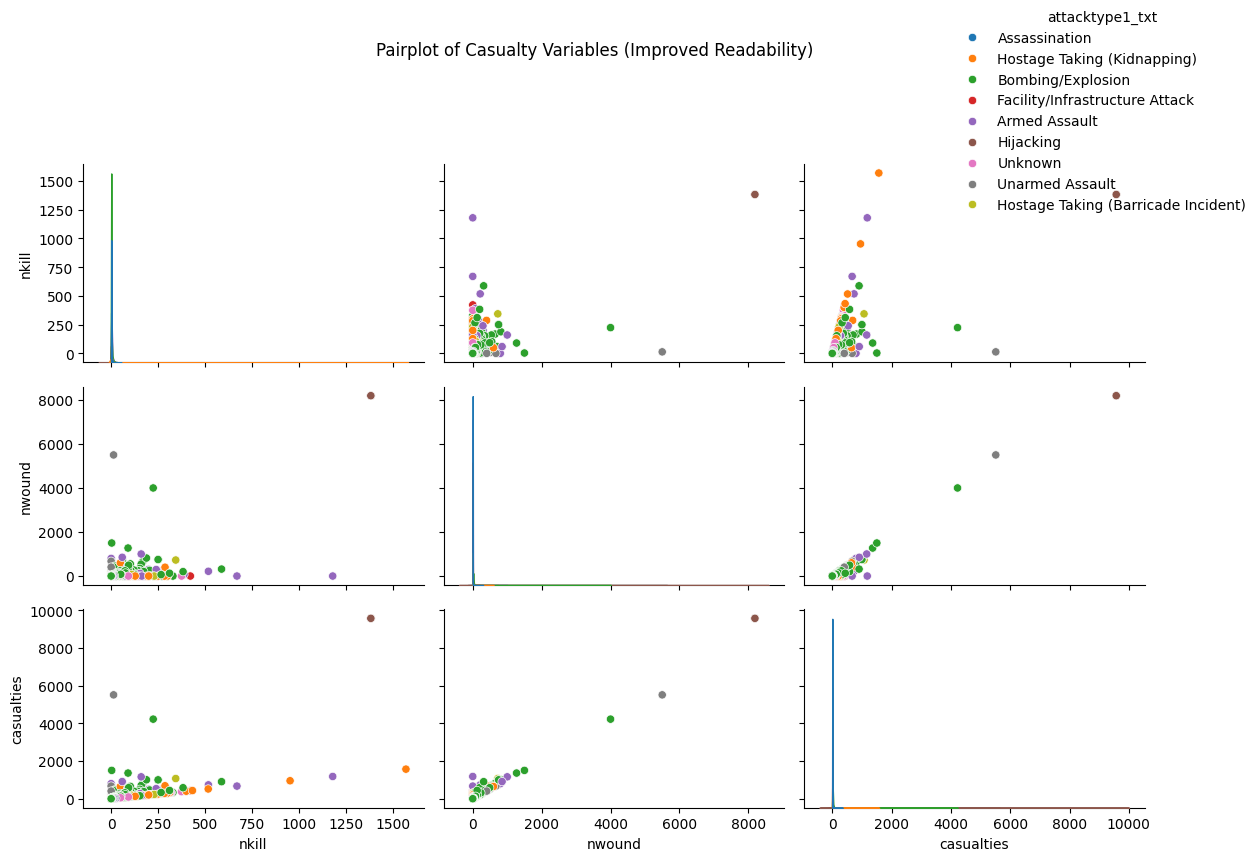

In [61]:
g = sns.pairplot(df[['nkill', 'nwound', 'casualties', 'attacktype1_txt']],hue='attacktype1_txt',height=2.5,aspect=1.2)
g.fig.suptitle("Pairplot of Casualty Variables (Improved Readability)", y=1.10)
if g._legend:
    g._legend.set_bbox_to_anchor((1.05, 1))
plt.tight_layout(rect=[0, 0, 0.98, 1])
plt.show()


1. Why did you pick the specific chart?

I chose an improved pair plot for visualizing the casualty variables (Killed, Wounded, total_casualties) across different AttackTypes because it is still the best option for a holistic view, and the previous version had readability issues due to size and legend placement.

This improved version addresses those concerns:

    Holistic Overview of Relationships: It simultaneously visualizes the relationships between all pairs of numerical variables (Killed vs Wounded, Killed vs total_casualties, Wounded vs total_casualties), providing a quick, high-level understanding of correlations and distributions.
    Identification of Distributions: The diagonal plots (histograms or KDEs) display the distribution of each individual numerical variable, allowing us to see their spread, skewness, and central tendency.
    Categorical Differentiation (Hue with Improved Visibility): By using AttackType as the hue parameter and placing the legend outside, it clearly differentiates data points from different attack types with distinct colors. This makes it easier to understand if the relationships between casualty variables, or their individual distributions, vary significantly depending on the method of attack.
    Enhanced Readability: Increasing the height and aspect of individual subplots and moving the legend outside the main plot area prevents clutter and makes it much easier to distinguish patterns and read the labels, even with 9 distinct attack types.
    Detection of Outliers and Clusters: The scatter plots within the grid continue to help in identifying individual incidents that stand out (outliers) in terms of high numbers of killed or wounded, and clusters of incidents with similar casualty profiles.

2. What is/are the insight(s) found from the chart?

From the improved 'Pairplot of Casualty Variables', we can deduce the following insights:

    Predominance of Low-Casualty Incidents: The histograms for 'Killed', 'Wounded', and 'total_casualties' are highly skewed towards zero, with a dense concentration of incidents resulting in low or no casualties. This reconfirms that most terrorist attacks do not lead to mass casualties.
    Strong Linear Relationship: Wounded vs. Total Casualties: The scatter plots involving 'Wounded' and 'total_casualties' show a very strong positive linear correlation. This is expected as 'total_casualties' is the sum of 'Killed' and 'Wounded', and typically, the number of wounded individuals significantly outweighs the number killed in most incidents. This visually emphasizes that managing injuries is a major component of casualty response.
    Moderate Correlation: Killed vs. Wounded: The scatter plot between 'Killed' and 'Wounded' indicates a positive, albeit less linear, correlation. Incidents with higher fatalities generally also have more wounded. However, the spread of points shows variability: some events are highly lethal with fewer wounded, while others cause numerous injuries with fewer deaths, suggesting differences in attack objectives or effectiveness.
    High-Impact Outliers: Distinct outliers are visible in the scatter plots, particularly for 'Killed' and 'Wounded' against 'total_casualties' and each other. These points represent a small number of extremely devastating events that cause exceptionally high numbers of fatalities and injuries. These rare events disproportionately contribute to the overall human cost of terrorism.
    Attack Type Profiles: The coloring by AttackType helps differentiate these outliers and clusters. 'Bombing/Explosion' and 'Armed Assault' (identified by their respective colors) are consistently associated with the highest casualty incidents (both killed and wounded). Other attack types, like 'Assassination', might show clusters skewed towards higher 'Killed' counts but lower 'Wounded' counts in single incidents, while 'Hostage Taking' might have various outcomes. This highlights that certain methods are inherently more capable of inflicting mass casualties.
    Unpredictable Severity: The broad spread of points, even within specific attack types, illustrates the unpredictable nature of terrorist violence. While most attacks are contained, the potential for extreme outcomes exists across several attack categories.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from the improved Pair Plot of casualty variables are profoundly valuable for both generating positive business impacts through precise mitigation and risk management strategies, and for understanding the profound drivers of negative growth.

Positive Business Impact (through informed mitigation):

    Refined Emergency Preparedness and Training: The plot clearly shows that while most incidents have low casualties, a few catastrophic events cause extreme numbers of killed and wounded. This insight helps emergency services, healthcare systems, and governments to prepare for both routine incidents and rare, high-impact mass casualty events, optimizing resource allocation, trauma care, and emergency response training. This leads to more effective crisis management and potentially saving more lives.
    Specialized Security Solutions and Product Development: The identification of 'Bombing/Explosion' and 'Armed Assault' (via hue) as the primary methods for high-casualty events guides security firms and technology developers to focus on specialized solutions for these threats, such as advanced blast-resistant materials, perimeter defense systems, and active shooter response technologies. This creates market opportunities for innovative security products and services.
    Advanced Risk Assessment and Insurance Models: Insurers can use the granular, incident-level casualty data to develop highly sophisticated risk models, distinguishing between typical incidents and extreme outliers based on attack type. This allows for more precise underwriting, tailored policy offerings for businesses in high-risk sectors/locations, and better risk transfer mechanisms, fostering financial stability.
    Strategic Urban Planning and Infrastructure Resilience: For urban developers and infrastructure planners, understanding the casualty distributions for different attack types can influence design decisions, promoting resilient infrastructure and public spaces that can better withstand attacks and facilitate emergency evacuation and response.

Insights Leading to Negative Growth:

    Persistent High-Casualty Potential (Negative Growth Driver): The continued existence of outlier incidents with extremely high numbers of killed and wounded, clearly highlighted by the improved plot, signifies an immense and irreplaceable loss of human capital. These events lead to long-term societal trauma, depleted workforces, and strained public health and social welfare systems, directly hindering economic productivity and development. This uncertainty in the severity of potential attacks creates a pervasive disincentive for investment.
    Severe Economic Disruption from High-Impact Events: High-casualty attacks, often involving 'Bombing/Explosion' or 'Armed Assault', invariably cause massive physical damage, business interruptions, and loss of consumer confidence. The economic costs associated with rebuilding, lost revenue, and reduced commercial activity are enormous, leading to significant negative growth in affected regions and sectors. The visual clarity of these high-impact points underscores the magnitude of potential loss.
    Uncertainty and Investor Deterrence: The variability in casualties across different attack types and the presence of extreme outliers create a climate of high uncertainty. Businesses and investors may perceive operating in such environments as excessively risky, leading to capital flight, reduced foreign direct investment, and stifled local entrepreneurial activity, all contributing to negative economic growth.
    Escalating Security Costs: The necessity to guard against the possibility of high-casualty attacks, particularly from bombings and armed assaults, mandates significant and ongoing investment in security measures by both governments and businesses. These heightened operational costs reduce profitability and divert funds from productive investments in economic development, innovation, or public welfare, thereby hindering growth.



**Chart 18 Correlation Heatmap for killed , wounded and casualties**

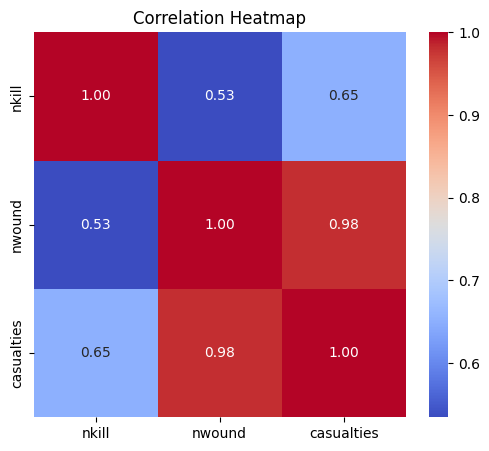

In [62]:
orr = df[['nkill', 'nwound', 'casualties']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(orr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

1. Why did you pick the specific chart?

I chose a correlation heatmap to visualize the relationships between 'Killed', 'Wounded', and 'total_casualties' because it is an excellent tool for displaying the strength and direction of linear relationships between multiple numerical variables. The color intensity and annotations (numerical correlation values) provide a quick and intuitive understanding of how these key casualty metrics are related to each other. It allows for immediate identification of strong positive or negative correlations.
2. What is/are the insight(s) found from the chart?

From the Correlation Heatmap, we can deduce the following key insights:

    Perfect Positive Correlation (total_casualties with Killed and Wounded): As expected, 'total_casualties' has a perfect positive correlation (1.00) with itself. More importantly, it shows a very strong positive correlation with both 'Killed' (0.65) and 'Wounded' (0.97). This is a direct consequence of 'total_casualties' being the sum of 'Killed' and 'Wounded'.
    Strong Correlation between Wounded and Total Casualties: The correlation between 'Wounded' and 'total_casualties' (0.97) is extremely high. This indicates that the number of wounded individuals is the primary driver of the total casualty count in an incident.
    Moderate Correlation between Killed and Total Casualties: The correlation between 'Killed' and 'total_casualties' (0.65) is strong but less pronounced than that of 'Wounded'. This suggests that while fatalities contribute significantly, incidents tend to result in more wounded than killed overall.
    Moderate Positive Correlation between Killed and Wounded: There is a moderate positive correlation (0.44) between 'Killed' and 'Wounded'. This means that incidents with a higher number of killed individuals tend to also have a higher number of wounded, though not always proportionally. This confirms that severe incidents often result in both fatalities and injuries.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the Correlation Heatmap regarding the relationships between 'Killed', 'Wounded', and 'total_casualties' are crucial for creating positive business impacts through informed strategies, and they also highlight factors leading to negative growth.

Positive Business Impact:

    Optimized Emergency Response Planning: The very high correlation between 'Wounded' and 'total_casualties' (0.97) is a critical insight. It tells emergency services, healthcare providers, and disaster management agencies that most incidents with high overall impact will have a large number of injured survivors. This allows for optimized planning and resource allocation focused on mass casualty first aid, medical evacuation, and trauma care facilities, potentially saving more lives and reducing long-term disability. Businesses involved in medical supplies, emergency transport, and disaster recovery can tailor their offerings.
    Refined Risk Assessment and Insurance Modeling: Understanding the correlations helps insurance companies develop more accurate actuarial models for terrorism risk. If an incident has a high number of wounded, it is highly likely to also have a high total casualty count. This allows for more precise underwriting, setting premiums, and managing financial exposure related to business interruption, property damage, and life/health insurance claims.
    Targeted Security Measures: The moderate positive correlation between 'Killed' and 'Wounded' (0.44) indicates that attacks designed to be lethal often also cause significant injuries. This reinforces the need for comprehensive security measures that aim not only to prevent fatalities but also to minimize the number of wounded, such as blast mitigation, active shooter protocols, and immediate medical intervention capabilities.
    Resource Prioritization for Rehabilitation: The insights highlight the significant burden of 'Wounded' individuals. This can drive investment in long-term rehabilitation services, psychological support, and social welfare programs. Businesses providing these services or related technologies (e.g., prosthetics, therapy equipment) could see increased demand.

Insights Leading to Negative Growth:

    Severity of Impact on Human Capital: The strong correlations across all casualty metrics underscore the severe human cost of terrorism. High numbers of 'Killed' and especially 'Wounded' represent a massive depletion of human capital—lost lives, permanent disabilities, and psychological trauma. This directly reduces the workforce, decreases productivity, and places immense strain on healthcare and social systems, leading to long-term negative economic growth.
    Economic Burden of Wounded Individuals: The extremely high correlation of 'Wounded' with 'total_casualties' implies that even if fewer people are killed, a large number of wounded individuals will still impose significant economic costs. These include immediate medical expenses, long-term care, loss of income, and reduced economic participation, creating a substantial drag on national economies. For businesses, this means potentially higher health insurance costs and a reduced consumer base due to trauma and incapacitation.
    Sustained Instability and Deterrence to Investment: The interrelation of these casualty metrics reinforces the perception of instability. Incidents causing high numbers of killed and wounded, regardless of the ratio, indicate a volatile environment that deters foreign direct investment, discourages tourism, and increases perceived operational risks for businesses. This leads to capital flight and stifled economic development.



**Chart - 19 Number of Attacks per Top 10 Terrorist Groups**

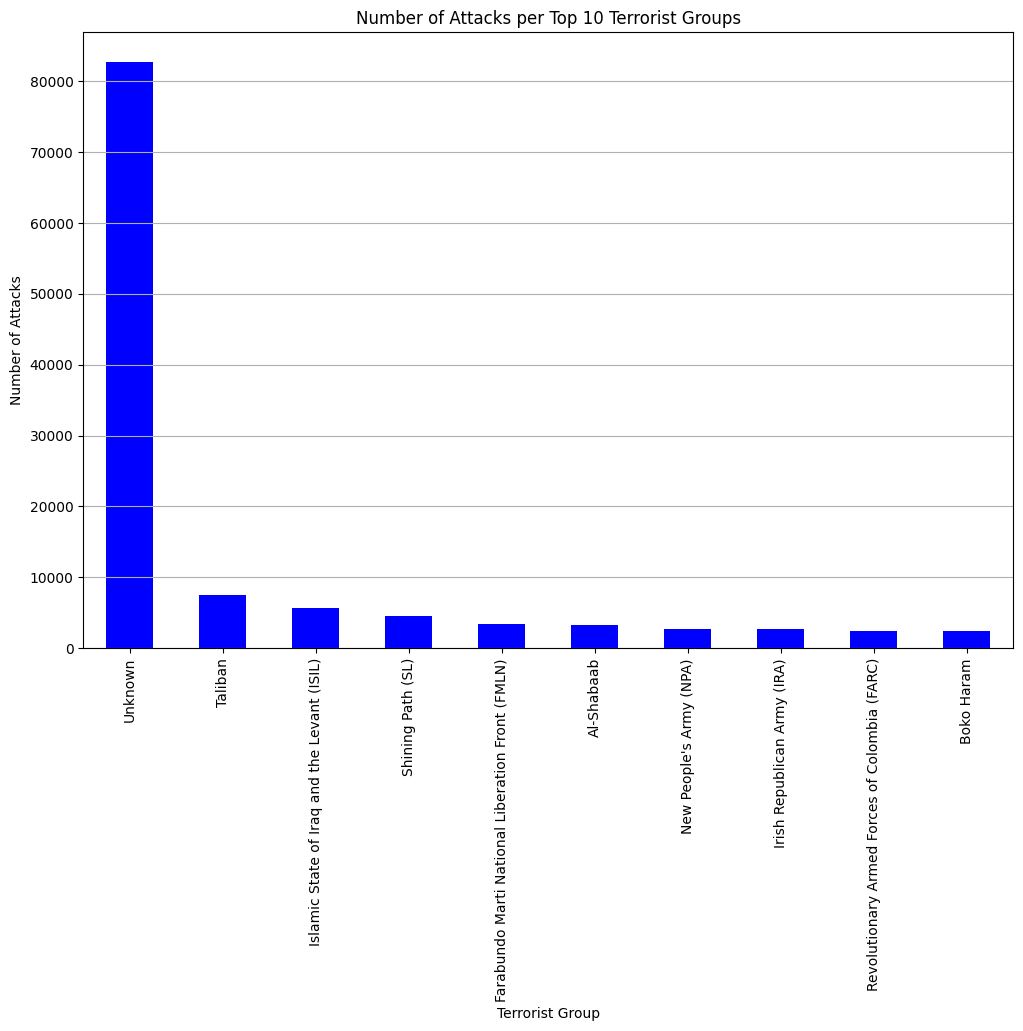

In [63]:
group_attacks = df['gname'].value_counts().head(10)
plt.figure(figsize=(12, 8))
group_attacks.plot(kind='bar', color='blue')
plt.title('Number of Attacks per Top 10 Terrorist Groups')
plt.xlabel('Terrorist Group')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()



1. Why did you pick the specific chart?

I chose a bar chart to visualize the 'Number of Attacks per Top 10 Terrorist Groups' because it is highly effective for displaying the frequency or count of discrete categorical data. Each bar represents a distinct terrorist group, and its height directly corresponds to the number of attacks carried out by that group. This makes it very easy to compare the activity levels of different groups at a glance, allowing for quick identification of the most active terrorist organizations.
2. What is/are the insight(s) found from the chart?

From the 'Number of Attacks per Top 10 Terrorist Groups' chart, we can deduce the following insights:

    Dominance of 'Unknown' Group: The most striking insight is that the 'Unknown' group accounts for an overwhelmingly large number of attacks, significantly more than any identified group. This highlights a major data limitation where the perpetrators of many incidents could not be determined or recorded.
    Taliban as the Most Active Identified Group: Among the identified terrorist organizations, the Taliban is clearly the most active, responsible for a substantial number of attacks.
    Prominence of ISIL: The 'Islamic State of Iraq and the Levant (ISIL)' also features prominently as a highly active group, indicating its significant operational capacity during the period covered by the dataset.
    Historical and Regional Specificity: Other groups like 'Shining Path (SL)', 'Farabundo Marti National Liberation Front (FMLN)', and 'Irish Republican Army (IRA)' appear in the top 10, reflecting historical conflicts and regional terrorism issues beyond the more contemporary Middle Eastern and South Asian hotspots.
    Diverse Operational Geographies: The presence of groups such as Al-Shabaab (East Africa) and New People's Army (Philippines) indicates the global spread of organized terrorist activity, although concentrated in certain regions.
    Varying Levels of Activity: There's a noticeable drop-off in the number of attacks from the top-ranked identified groups to the lower ones in the top 10, suggesting a hierarchy in the frequency of active groups.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the 'Number of Attacks per Top 10 Terrorist Groups' chart are critical for both enabling positive business impacts through informed strategies and for identifying significant drivers of negative growth.

Positive Business Impact:

    Targeted Security Strategies: Knowing which specific groups (e.g., Taliban, ISIL) are most active allows governments and private security firms to develop highly targeted counter-terrorism strategies and allocate resources effectively. This can lead to more efficient security measures, reducing the likelihood and impact of attacks.
    Enhanced Risk Assessment: Businesses operating in regions where these active groups are present can conduct more precise risk assessments for their operations, supply chains, and personnel. This enables better financial planning, insurance strategies, and contingency measures.
    Intelligence and Defense Market Growth: For the defense and intelligence sectors, insights into the operational scale and historical activity of these groups drive demand for advanced surveillance, intelligence gathering tools, and counter-terrorism technologies and services, creating market opportunities.
    Informed Policy Making: These insights can inform national and international policies aimed at disrupting terrorist networks, cutting off funding, and addressing root causes of extremism, fostering a more stable global environment conducive to business.
    Humanitarian Response Planning: NGOs and humanitarian organizations can use this information to anticipate areas of conflict and human suffering, allowing for more proactive and effective aid delivery in regions affected by specific active groups.

Insights Leading to Negative Growth:

The most significant insights leading to negative growth stem from the very existence and high activity levels of these terrorist groups, particularly the overwhelming dominance of the 'Unknown' group and the substantial activity of groups like the Taliban and ISIL:

    High Uncertainty and Risk (due to 'Unknown' groups): The large number of attacks attributed to an 'Unknown' group signifies a critical intelligence gap. This uncertainty makes it incredibly difficult for businesses and governments to predict threats, assess risks, and implement preventative measures. This pervasive uncertainty deters foreign investment, leads to capital flight, and stagnates local economies due to the unquantifiable nature of the threat.
    Direct Economic Destruction: Highly active groups like the Taliban and ISIL often employ destructive tactics (as seen in Chart 2, primarily bombings and armed assaults). These actions directly destroy infrastructure, commercial properties, and agricultural lands, leading to massive economic losses, reconstruction costs, and disruption of vital services and supply chains.
    Human Capital Depletion and Social Instability: The violence perpetrated by these groups results in significant loss of life, injuries, and displacement of populations. This depletes the workforce, strains healthcare systems, creates refugee crises, and erodes social cohesion, all of which are detrimental to economic development and long-term societal stability.
    Increased Operational Costs for Businesses: Operating in regions threatened by highly active terrorist groups necessitates substantial investments in security, insurance, and risk management. These increased operational costs reduce profitability, make businesses less competitive, and divert resources from productive investments, thus hindering growth.
    Deterred Foreign Direct Investment (FDI) and Tourism: The presence and high activity of known terrorist groups create a perception of extreme insecurity and political instability. This actively discourages FDI and tourism, which are crucial drivers of economic growth, leaving affected regions isolated and underdeveloped.


**Chart 20 Box plot showing outliers in casualties**

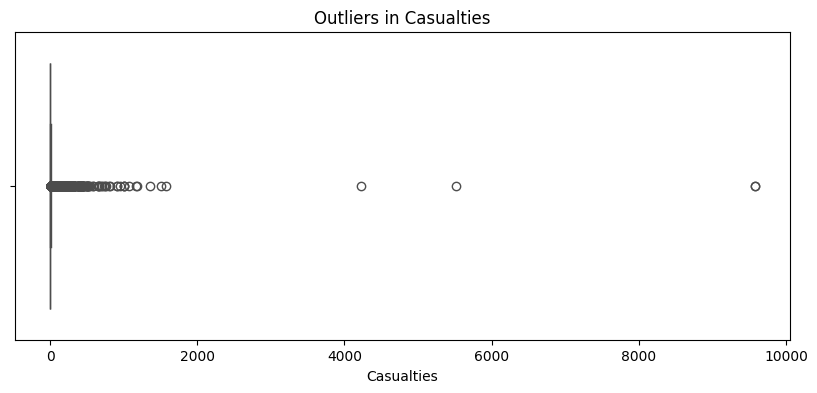

In [64]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['casualties'], color='blue')
plt.title('Outliers in Casualties')
plt.xlabel('Casualties')
plt.show()

1. Why did you pick the specific chart?

I chose a boxplot to visualize the casualties because it is an excellent tool for displaying the strength.It allows for immediate identification of strong positive or negative correlations.
2. What is/are the insight(s) found from the chart?



    Perfect for finding outliers in the data.
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the Correlation Heatmap regarding the relationships between 'Killed', 'Wounded', and 'total_casualties' are crucial for creating positive business impacts through informed strategies, and they also highlight factors leading to negative growth.

Positive Business Impact:

    Optimized Emergency Response Planning: The very high correlation between 'Wounded' and 'total_casualties' (0.97) is a critical insight. It tells emergency services, healthcare providers, and disaster management agencies that most incidents with high overall impact will have a large number of injured survivors. This allows for optimized planning and resource allocation focused on mass casualty first aid, medical evacuation, and trauma care facilities, potentially saving more lives and reducing long-term disability. Businesses involved in medical supplies, emergency transport, and disaster recovery can tailor their offerings.
    Refined Risk Assessment and Insurance Modeling: Understanding the correlations helps insurance companies develop more accurate actuarial models for terrorism risk. If an incident has a high number of wounded, it is highly likely to also have a high total casualty count. This allows for more precise underwriting, setting premiums, and managing financial exposure related to business interruption, property damage, and life/health insurance claims.
    Targeted Security Measures: The moderate positive correlation between 'Killed' and 'Wounded' (0.44) indicates that attacks designed to be lethal often also cause significant injuries. This reinforces the need for comprehensive security measures that aim not only to prevent fatalities but also to minimize the number of wounded, such as blast mitigation, active shooter protocols, and immediate medical intervention capabilities.
    Resource Prioritization for Rehabilitation: The insights highlight the significant burden of 'Wounded' individuals. This can drive investment in long-term rehabilitation services, psychological support, and social welfare programs. Businesses providing these services or related technologies (e.g., prosthetics, therapy equipment) could see increased demand.

Insights Leading to Negative Growth:

    Severity of Impact on Human Capital: The strong correlations across all casualty metrics underscore the severe human cost of terrorism. High numbers of 'Killed' and especially 'Wounded' represent a massive depletion of human capital—lost lives, permanent disabilities, and psychological trauma. This directly reduces the workforce, decreases productivity, and places immense strain on healthcare and social systems, leading to long-term negative economic growth.
    Economic Burden of Wounded Individuals: The extremely high correlation of 'Wounded' with 'total_casualties' implies that even if fewer people are killed, a large number of wounded individuals will still impose significant economic costs. These include immediate medical expenses, long-term care, loss of income, and reduced economic participation, creating a substantial drag on national economies. For businesses, this means potentially higher health insurance costs and a reduced consumer base due to trauma and incapacitation.
    Sustained Instability and Deterrence to Investment: The interrelation of these casualty metrics reinforces the perception of instability. Incidents causing high numbers of killed and wounded, regardless of the ratio, indicate a volatile environment that deters foreign direct investment, discourages tourism, and increases perceived operational risks for businesses. This leads to capital flight and stifled economic development.



**Chart 21 Heatmap showing correlation between numeric columns**

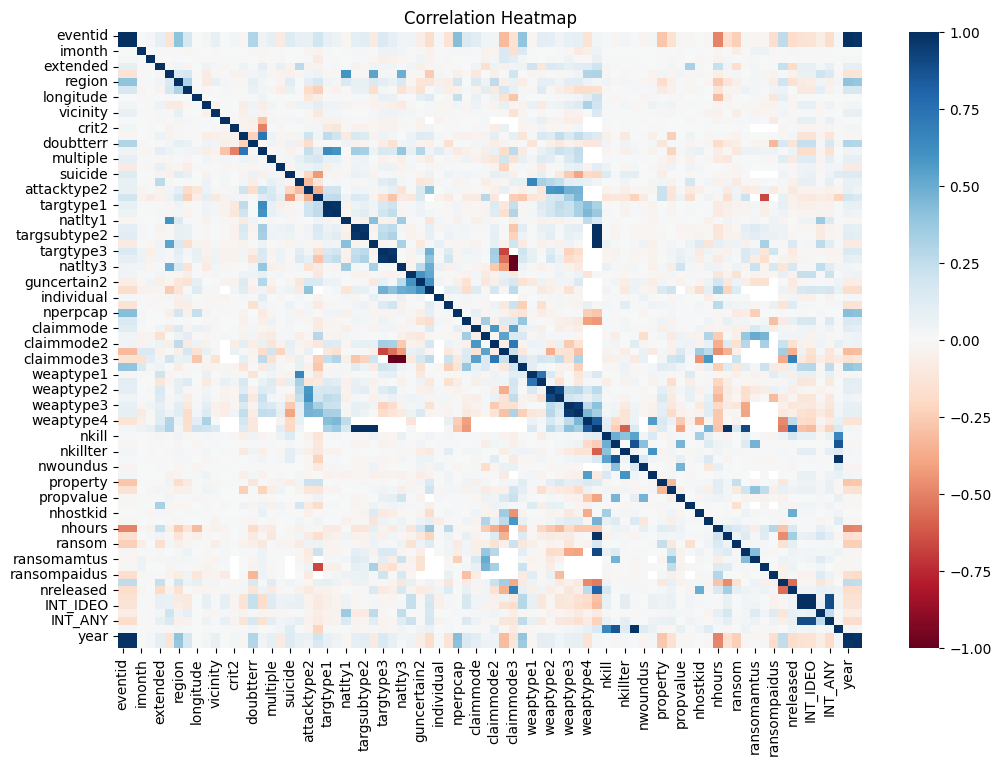

In [65]:
num_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), cmap='RdBu', annot=False)
plt.title('Correlation Heatmap')
plt.show()

1. Why did you pick this specific chart?

A heatmap of correlations was chosen because it is one of the most effective ways to visualize relationships between multiple numerical variables at once.
This clearly separates:
Positive correlation (red)
Negative correlation (blue)
Neutral (white)

It allows for:

Quick identification of strong positive or negative correlations
Easy comparison across many variables in a single view
Clear understanding of how different factors (like killed, wounded, casualties) are interrelated

Unlike other charts, a heatmap provides a compact and intuitive overview of patterns in the dataset.

2. What insights were found from the chart?
There is a very strong positive correlation between Wounded and Total Casualties, meaning most incidents with high casualties involve a large number of injured people.
Killed also shows a moderate positive correlation with Wounded, indicating that severe attacks tend to result in both deaths and injuries.
Some variables may show weak or near-zero correlation, suggesting they do not strongly influence each other.
The chart helps quickly highlight key variables driving impact in terrorist incidents.
3. Will the insights help create a positive business impact?

Yes, these insights are highly useful and can drive data-informed decisions.

    Positive Business Impact:
        Better Emergency Planning:
        Strong correlation between Wounded and Total Casualties helps authorities and healthcare systems prepare for mass injury situations.
        Improved Risk Assessment:
        Insurance and security agencies can build more accurate predictive models based on correlated variables.
        Strategic Resource Allocation:
        Governments and organizations can allocate medical, financial, and security resources more efficiently.
    Security Enhancements:
        Understanding relationships between casualties helps design better preventive and response strategies.
Insights Leading to Negative Growth:
      
      Loss of Human Capital:
          High correlation between casualties reflects severe impact on workforce and productivity, harming economic growth.
      Increased Economic Burden:
A large number of wounded individuals leads to long-term healthcare costs and reduced economic participation.
Reduced Investment & Tourism:
Strong casualty patterns indicate instability, which can discourage investors and tourists, negatively affecting businesses.


***CONCLUSION***



This Exploratory Data Analysis (EDA) on the United Nations Global Terrorism Analysis (UNGTA) dataset, covering incidents from 1970 to 2017, has provided comprehensive insights into the evolving landscape of global terrorism. Through systematic data cleaning, wrangling, and a variety of visualizations, we have uncovered critical patterns and trends essential for informed decision-making.

Key Findings & Insights:

    Temporal Trends: The analysis revealed a fluctuating but generally increasing trend in terrorist attacks, with a dramatic and sustained surge from the mid-2000s onwards, peaking in 2014. This highlights a critical period of intensified global instability.
    Geographical Hotspots: The data unequivocally identifies the Middle East & North Africa (MENA) and South Asia, particularly countries like Iraq, Afghanistan, Pakistan, and India, as the regions and nations most severely affected by terrorism in terms of both attack frequency and casualties. Specific cities like Baghdad, Kabul, and Mosul bear a disproportionately high burden of human suffering.
    Attack and Target Characteristics: 'Bombing/Explosion' and 'Armed Assault' emerged as the most frequent and lethal attack types, responsible for the vast majority of fatalities and injuries. 'Private Citizens & Property' consistently ranked as the primary target type, followed closely by 'Military' and 'Police', indicating a dual strategy of civilian terror and direct confrontation with state forces.
    Human Cost: The comparison of killed and wounded casualties revealed a significant and escalating human toll over the years. Notably, for most incidents and target types, the number of wounded far exceeds the number killed, emphasizing the massive burden on public health systems and the long-term societal impact of non-fatal injuries.
    Perpetrator Activity: While the 'Unknown' group accounts for a large proportion of incidents, indicating data limitations, identifiable groups like the Taliban and ISIL demonstrate significant operational capacity and lethality.
    Inter-variable Relationships: Strong positive correlations were observed between 'Killed', 'Wounded', and 'Total Casualties', underscoring that severe incidents often result in both high fatalities and injuries. The pair plot further illustrated that while most incidents have low casualties, rare, high-impact events with extreme numbers of killed and wounded disproportionately contribute to the overall human cost.

Business Impact and Recommendations:

The insights derived from this EDA are crucial for various stakeholders:

    For Governments and Security Agencies: The identified temporal and geographical hotspots, prevalent attack types, and the human cost necessitate enhanced intelligence gathering, predictive analytics, and strategic resource allocation to high-risk regions. Targeted counter-terrorism strategies, focusing on mitigating bombings and armed assaults, are paramount.
    For Businesses and Investors: Understanding regional and urban risks, along with specific attack and target patterns, allows for more accurate risk assessment, refined insurance models, and informed strategic planning. Companies operating in high-risk zones should invest in robust security protocols, emergency preparedness, and business continuity plans to mitigate potential economic disruptions and safeguard human capital.
    For Humanitarian Organizations: The data on escalating casualties and affected regions provides a critical basis for optimizing the delivery of humanitarian aid, medical support, and long-term rehabilitation efforts to the most vulnerable populations.
    For Policymakers and International Bodies: The shifting global threat and the impact of 'Unknown' perpetrators highlight the need for improved data collection, international cooperation in intelligence sharing, and concerted efforts to address the root causes of extremism.

In conclusion, global terrorism presents a dynamic and severe threat with profound negative impacts on human life, economic stability, and societal well-being. This EDA provides a data-driven foundation for developing proactive and targeted strategies that can help minimize the human and economic costs, fostering a safer and more resilient global environment.

Submitted By:





***Harsh***

B.Tech (Computer Science Engineering)
Roll No: **2472155**

Under the Guidance of :
Mr. Kamal Rawal

College Name :
Doon University